# Construcción de recursos léxicos para quechua

Este proyecto tiene como objetivo el procesamiento automático de un diccionario Quechua–Español en formato PDF, con el fin de transformarlo en un recurso digital estructurado y accesible.

Se implementaron técnicas de extracción y limpieza de texto mediante la librería **PyMuPDF**, identificando los lemas en **negrita**, eliminando encabezados y separando el contenido en dos secciones: Quechua→Español y Español→Quechua. Asimismo, se procesaron abreviaturas de categorías gramaticales, campos semánticos y variantes dialectales.

El texto fue convertido a un formato **JSON estructurado**, donde cada entrada contiene campos como lema, definición, categoría gramatical, sinónimos, ejemplos y variantes regionales. Además, se desarrolló el módulo `diccionario_utils.py`, que permite realizar búsquedas exactas y flexibles, conteo de entradas y consultas aleatorias.

El resultado es un recurso digital que facilita la consulta, análisis lingüístico y preservación del quechua, aportando a su estudio y aplicación en proyectos educativos y de procesamiento de lenguaje natural.


ALUMNOS:

FRANZ PAUL HUAMAN BERRIO			210930

BRUCE MÁXIMO MAMANI GABRIEL			182917

FERDINAN JUNIOR CONDORCAHUA AYLLONE	184194


In [1]:
!pip install pdfminer.six


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 94.1 MB/s eta 0:00:00


In [2]:
!pip install PyMuPDF --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 84.0 MB/s eta 0:00:00


# Leer Diccionario PDF

In [3]:
import fitz  # PyMuPDF
from pathlib import Path

pdf_path = "diccionario-qeswa-academia-mayor.pdf"
out_txt = Path("diccionario_raw.txt")

doc = fitz.open(pdf_path)
all_text = []

for i, page in enumerate(doc, start=1):
    page_text = []

    blocks = page.get_text("dict")["blocks"]
    blocks_sorted = sorted(blocks, key=lambda b: (round(b.get("bbox", [0])[0] // 100), b.get("bbox", [0, 0])[1]))

    for b in blocks_sorted:
        if "lines" not in b:
            continue
        for line in b["lines"]:
            line_text = ""
            for span in line["spans"]:
                text = span["text"].strip()
                if not text:
                    continue
                # Detectar solo negritas mirando la fuente
                font_name = span.get("font", "")
                if "Bold" in font_name:
                    text = f"**{text}**"
                line_text += text + " "
            if line_text.strip():
                page_text.append(" ".join(line_text.strip().split()))

    all_text.append(f"\n\n=== PAGE:{i} ===\n\n" + "\n".join(page_text))

full_text = "\n".join(all_text)
out_txt.write_text(full_text, encoding="utf-8")
print("Texto crudo con negritas guardado en:", out_txt)


Texto crudo con negritas guardado en: diccionario_raw.txt


## Separar Quechua-Español y Español-Quechua


In [4]:
from pathlib import Path
import re

raw_txt_path = Path("diccionario_raw.txt")
full_text = raw_txt_path.read_text(encoding="utf-8")

# Separar páginas
pages = full_text.split("\n\n=== PAGE:")
pages = [p if p.startswith("=== PAGE:") else "=== PAGE:" + p for p in pages]

clean_pages = []
for p in pages:
    lines = p.splitlines()
    if not lines:
        continue

    # Eliminar header "=== PAGE:x ==="
    body = lines[1:]

    # --- limpieza: eliminar encabezados repetitivos ---
    body = [
        l for l in body
        if not re.match(r"^\*\*[A-Z]\*\*(\s+\*\*[A-Z]+\*\*)+$", l.strip())  # **D** **ICCIONARIO**, **S** **IMI** **T** **AQE**
        and not re.match(r"^◄\s*●\s*►$", l.strip())                          # símbolos decorativos
        and not re.match(r"^\d+$", l.strip())                                # números de página solos
        and not l.strip().startswith("**QUECHUA")                            # cabecera sección
        and not l.strip().startswith("**QHESWA")                             # cabecera sección
        and not re.match(r"^\*\*[A-Z]\*\*$", l.strip())                      # letras índice solas (**A**, **B**)
    ]

    # Quitar líneas vacías
    body = [l for l in body if l.strip()]

    # Guardar todo el contenido limpio de la página
    clean_pages.append("\n".join(body))

# Unir páginas sin doble salto de línea
qe_pages = clean_pages[13:249]
eq_pages = clean_pages[249:298]

Path("quechua_espanol.txt").write_text("\n".join(qe_pages), encoding="utf-8")
Path("espanol_quechua.txt").write_text("\n".join(eq_pages), encoding="utf-8")

print("Archivos limpios generados:")
print(" - quechua_espanol.txt")
print(" - espanol_quechua.txt")

Archivos limpios generados:
 - quechua_espanol.txt
 - espanol_quechua.txt


In [5]:
from pathlib import Path

txt_path = Path("diccionario_raw.txt")
out_path = Path("variantes_dialectales.txt")

# Leer todo el archivo
with txt_path.open(encoding="utf-8") as f:
    lines = f.readlines()

# Buscar inicio y fin de página 10
start_idx = None
end_idx = None
for i, line in enumerate(lines):
    if line.startswith("=== PAGE:10 ==="):
        start_idx = i + 1  # empezar después de la marca de página
    elif line.startswith("=== PAGE:11 ===") and start_idx is not None:
        end_idx = i
        break

# Extraer líneas de la página 10
page10_lines = lines[start_idx:end_idx]

# Rangos de líneas para variantes dialectales
# Primer bloque: líneas 6 a 34 (index 5 a 33)
# Segundo bloque: líneas 198 a 210 aprox (index 197 a 209)
ranges = [(8, 36), (177, 189)]

# Unir los bloques en una sola lista
variantes_lines = []
for r in ranges:
    variantes_lines.extend(page10_lines[r[0]:r[1]])

# Guardar en un nuevo archivo
with out_path.open("w", encoding="utf-8") as f:
    f.writelines(variantes_lines)

print(f"Variantes dialectales guardadas en: {out_path}")


Variantes dialectales guardadas en: variantes_dialectales.txt


In [6]:
import re
from pathlib import Path

txt_path = Path("diccionario_raw.txt")

with txt_path.open(encoding="utf-8") as f:
    lines = f.readlines()

# Página 10
start_idx = None
end_idx = None
for i, line in enumerate(lines):
    if line.startswith("=== PAGE:10 ==="):
        start_idx = i + 1
    elif line.startswith("=== PAGE:11 ===") and start_idx is not None:
        end_idx = i
        break

page10_lines = lines[start_idx:end_idx]

# Rangos de líneas para variantes dialectales
ranges = [(8, 36), (177, 189)]
variantes_lines = []
for r in ranges:
    variantes_lines.extend(page10_lines[r[0]:r[1]])

variantes_dict = {}

# Procesar países del área andina (hasta Perú)
i = 0
while i < len(variantes_lines):
    line = variantes_lines[i].strip()
    if re.match(r"\d+\.\s*Pe\.", line):  # inicio de regiones de Perú
        break
    match = re.match(r"\d+\.\s*(\w+)\.?", line)
    if match:
        abrev = match.group(1)
        name = variantes_lines[i+1].strip()
        variantes_dict[abrev] = name
        i += 2
        continue
    i += 1

# Procesar regiones lingüísticas de Perú
while i < len(variantes_lines):
    line = variantes_lines[i].strip()
    # ignorar líneas vacías
    if not line:
        i += 1
        continue
    # Extraer abreviatura
    abrev_match = re.match(r"\d+\.\s*(Pe\.[A-Za-z]+)", line)
    if abrev_match:
        abrev = abrev_match.group(1)
        # La línea siguiente es el nombre completo
        name = variantes_lines[i+1].strip()
        variantes_dict[abrev] = name
        i += 2
    else:
        i += 1

# Mostrar resultado
for k, v in variantes_dict.items():
    print(f"{k}: {v}")


Arg: Argentina
Bol: Bolivia
Col: Colombia
Chil: Chile
Ec: Ecuador
Pe.Anc: Perú Ancash
Pe.Apu: Perú Apurímac
Pe.Ama: Perú Amazonas
Pe.Areq: Perú Arequipa
Pe.Aya: Perú Ayacucho
Pe.Caj: Perú Cajamarca
Pe.LaLib: Perú La Libertad
Pe.Qos: Perú Qosqo
Pe.Huanc: Perú Huánuco
Pe.Huanv: Perú Huancavelica
Pe.Jun: Perú Junín
Pe.Pun: Perú Puno
Pe.S: Perú San Martín.


In [7]:
from pathlib import Path

txt_path = Path("diccionario_raw.txt")

with txt_path.open(encoding="utf-8") as f:
    lines = f.readlines()

# Página 10
start_idx_10 = None
end_idx_10 = None
for i, line in enumerate(lines):
    if line.startswith("=== PAGE:10 ==="):
        start_idx_10 = i + 1
    elif line.startswith("=== PAGE:11 ===") and start_idx_10 is not None:
        end_idx_10 = i
        break
page10_lines = lines[start_idx_10:end_idx_10]

# Página 11
start_idx_11 = None
end_idx_11 = None
for i, line in enumerate(lines):
    if line.startswith("=== PAGE:11 ==="):
        start_idx_11 = i + 1
    elif line.startswith("=== PAGE:12 ===") and start_idx_11 is not None:
        end_idx_11 = i
        break
page11_lines = lines[start_idx_11:end_idx_11]

# Rangos por página
ranges_page10 = [(37, 178), (206, 345)]
ranges_page11 = [(4, 29), (117, 163)]

abreviaturas_dict = {}

# Procesar página 10
for r in ranges_page10:
    sub_lines = page10_lines[r[0]:r[1]]
    i = 0
    while i < len(sub_lines):
        abrev = sub_lines[i].strip()
        if not abrev:
            i += 1
            continue
        if i + 1 < len(sub_lines):
            significado = sub_lines[i + 1].strip()
            abreviaturas_dict[abrev] = significado
            i += 2
        else:
            i += 1

# Procesar página 11
for r in ranges_page11:
    sub_lines = page11_lines[r[0]:r[1]]
    i = 0
    while i < len(sub_lines):
        abrev = sub_lines[i].strip()
        if not abrev:
            i += 1
            continue
        if i + 1 < len(sub_lines):
            significado = sub_lines[i + 1].strip()
            abreviaturas_dict[abrev] = significado
            i += 2
        else:
            i += 1

# Separar categorías gramaticales, campos semánticos y otros (sinón., ejem.)
cat_gram_set = {
    "s.", "v.", "adj.", "adv.", "pron.", "prep.", "conj.", "interj.",
    "f.", "m.", "sing.", "pl.", "imper.", "infínit.", "loc.", "loc.adv."
}

cat_gramatical = {}
camp_semantico = {}
otros_abreviaturas = {}

for abrev, significado in abreviaturas_dict.items():
    if abrev in cat_gram_set:
        cat_gramatical[abrev] = significado
    elif abrev in {"sinón.", "ejem."}:
        # separar explícitamente estas dos
        otros_abreviaturas[abrev] = significado
    else:
        camp_semantico[abrev] = significado
camp_semantico["insult."] = "insulto"


print("Categorías gramaticales:")
for k, v in cat_gramatical.items():
    print(f"{k}: {v}")

print("\nCampos semánticos:")
for k, v in camp_semantico.items():
    print(f"{k}: {v}")

print("\nOtras abreviaturas:")
for k, v in otros_abreviaturas.items():
    print(f"{k}: {v}")


Categorías gramaticales:
adj.: adjetivo
adv.: adverbio
conj.: conjunción
f.: femenino
imper.: imperativo
infínit.: infinitivo
interj.: interjección
loc.: locución
loc.adv.: locución adverbial
m.: masculino
pl.: plural
prep.: preposición
pron.: pronombre
s.: sustantivo
sing.: singular
v.: verbo

Campos semánticos:
Acust.: Acústica
Adm.: Administración
Agri.: Agricultura
Agrim.: Agrimensura
Alba.: Albanillería
alfab.: alfabeto
alim.: alimentación
Anat.: Anatomía
antón.: antónimo
Antrop.: Antropología
Apic.: Apicultura
apóc.: apócope
Arq.: Arquitectura
Arqueol.: Arqueología
Art.: Arte
Astrol.: Astrología
Astron.: Astronomía
bibliogr.: bibliografía
Biol.: Biología
Bot.: Botánica
Brom.: Bromatología
calend.: calendario
Carp.: Carpintería
Cast.: Castellano
Cerám.: Cerámica
Cerám.Ink.: cerámica inka
Cir.: Cirugía
Clim.: Climatología
comer.: comercio
Comu.: Comunicación
Cronol.: Cronología
Cunic.: Cunicultura
dep.: departamento
Dere.: Derecho
diminut.: diminutivo
dist.: distrito
Econ.: Economí

In [8]:
print(variantes_dict)
print(cat_gramatical)
print(camp_semantico)
print(otros_abreviaturas)

{'Arg': 'Argentina', 'Bol': 'Bolivia', 'Col': 'Colombia', 'Chil': 'Chile', 'Ec': 'Ecuador', 'Pe.Anc': 'Perú Ancash', 'Pe.Apu': 'Perú Apurímac', 'Pe.Ama': 'Perú Amazonas', 'Pe.Areq': 'Perú Arequipa', 'Pe.Aya': 'Perú Ayacucho', 'Pe.Caj': 'Perú Cajamarca', 'Pe.LaLib': 'Perú La Libertad', 'Pe.Qos': 'Perú Qosqo', 'Pe.Huanc': 'Perú Huánuco', 'Pe.Huanv': 'Perú Huancavelica', 'Pe.Jun': 'Perú Junín', 'Pe.Pun': 'Perú Puno', 'Pe.S': 'Perú San Martín.'}
{'adj.': 'adjetivo', 'adv.': 'adverbio', 'conj.': 'conjunción', 'f.': 'femenino', 'imper.': 'imperativo', 'infínit.': 'infinitivo', 'interj.': 'interjección', 'loc.': 'locución', 'loc.adv.': 'locución adverbial', 'm.': 'masculino', 'pl.': 'plural', 'prep.': 'preposición', 'pron.': 'pronombre', 's.': 'sustantivo', 'sing.': 'singular', 'v.': 'verbo'}
{'Acust.': 'Acústica', 'Adm.': 'Administración', 'Agri.': 'Agricultura', 'Agrim.': 'Agrimensura', 'Alba.': 'Albanillería', 'alfab.': 'alfabeto', 'alim.': 'alimentación', 'Anat.': 'Anatomía', 'antón.': 'a

In [9]:
import re

def eliminar_titulos_documento(texto):
    """
    Elimina títulos del documento que no son lemas.
    """
    titulos_eliminar = [
        r'\*\*ESPAÑOL\s*-\s*QUECHUA\*\*',
        r'\*\*ESPAÑOL\s*-\s*QHESWA\*\*',
        r'\*\*QUECHUA\s*-\s*ESPAÑOL\*\*',
        r'\*\*QHESWA\s*-\s*ESPAÑOL\*\*',
    ]

    for patron in titulos_eliminar:
        texto = re.sub(patron, '', texto, flags=re.IGNORECASE)

    return texto

def unir_lemas_divididos(texto):
    """
    Une lemas que están divididos en múltiples negritas.
    Caso 1: **caedizo,** – **za.** → **caedizo,–za.**
    Caso 2: **texto1** **texto2** → **texto1 texto2**
    """
    # Caso 1: **texto1** – **texto2** (con guión en medio)
    texto = re.sub(
        r'\*\*([^*]+?)\*\*\s*–\s*\*\*([^*]+?)\*\*',
        r'**\1–\2**',
        texto
    )

    # Caso 2: **texto1** **texto2** (consecutivos, solo al inicio de línea)
    # Pero NO si el segundo es una categoría gramatical
    def unir_si_no_es_categoria(match):
        texto1 = match.group(1)  # Incluye el ** inicial
        texto2 = match.group(2)  # Incluye el ** final

        # Limpiar texto2 para verificar
        texto2_sin_asteriscos = texto2.replace('**', '').strip()

        # Verificar si texto2 es una categoría gramatical
        if texto2_sin_asteriscos.lower() in {c.lower() for c in cat_gramatical.keys()}:
            # Es categoría gramatical, quitar negrita del segundo pero no unir
            return f'{texto1}** {texto2_sin_asteriscos}'
        else:
            # No es categoría, unir ambos como un solo lema
            # texto1 ya tiene ** al inicio, texto2 ya tiene ** al final
            return f'{texto1} {texto2_sin_asteriscos}**'

    texto = re.sub(
        r'^(\*\*[^*]+?)\*\*\s*\*\*([^*]+?\*\*)',
        unir_si_no_es_categoria,
        texto,
        flags=re.MULTILINE
    )

    return texto

def limpiar_negritas_dentro_palabras(texto):
    """
    Limpia negritas que están dentro de palabras (como semistria**t**us)
    """
    texto = re.sub(
        r'([a-záéíóúñA-ZÁÉÍÓÚÑ])\*\*([a-záéíóúñA-ZÁÉÍÓÚÑ]{1,3})\*\*([a-záéíóúñA-ZÁÉÍÓÚÑ])',
        r'\1\2\3',
        texto
    )
    return texto

def es_lema_valido(texto_negrita, es_inicio_linea, linea_anterior_termina_punto):
    """
    Determina si un texto en negrita es un lema válido.

    Un lema es válido si:
    1. Está al inicio de línea Y
    2. (La línea anterior termina en punto O el propio lema termina en punto)
    """
    if not es_inicio_linea:
        return False

    # Verificar si el lema termina en punto (antes de quitar el **)
    lema_termina_punto = texto_negrita.rstrip().endswith('.')

    # Es válido si línea anterior termina en punto O el lema termina en punto
    return linea_anterior_termina_punto or lema_termina_punto

def quitar_negritas_subsecciones(texto):
    """
    Quita las ** de subsecciones que NO son lemas válidos.
    """
    resultado = []
    lineas = texto.split('\n')

    linea_anterior_termina_punto = True  # Inicio del documento

    for linea in lineas:
        linea_procesada = linea

        # Buscar todos los **...** en esta línea
        matches = list(re.finditer(r'\*\*([^*]+?)\*\*', linea))

        if matches:
            offset = 0
            primer_match_es_lema = False

            for idx, match in enumerate(matches):
                texto_negrita = match.group(1)
                inicio = match.start() + offset
                fin = match.end() + offset

                # Verificar si está al inicio de la línea
                texto_antes = linea_procesada[:inicio].strip()
                es_inicio_linea = len(texto_antes) == 0

                # Para el primer match, verificar si es lema válido
                if idx == 0:
                    primer_match_es_lema = es_lema_valido(
                        texto_negrita,
                        es_inicio_linea,
                        linea_anterior_termina_punto
                    )

                # Si es el primer match y es lema válido, mantener **
                # Si no es el primer match pero el primero fue lema, ya se unieron (mantener)
                if idx == 0 and primer_match_es_lema:
                    continue  # Mantener las **

                # Si no es lema válido, quitar ** pero mantener texto
                nuevo_texto = linea_procesada[:inicio] + texto_negrita + linea_procesada[fin:]
                offset -= 4
                linea_procesada = nuevo_texto

        resultado.append(linea_procesada)

        # Actualizar si esta línea termina con punto u otro final válido
        linea_limpia = linea_procesada.strip()
        if linea_limpia:
            # Considerar punto, paréntesis cerrado, corchete cerrado
            linea_anterior_termina_punto = linea_limpia.endswith(('.', ')'))

    return '\n'.join(resultado)

def preprocesar_archivo(nombre_entrada, nombre_salida):
    """
    Procesa un archivo de diccionario y genera la versión limpia.
    """
    print(f"\n📖 Procesando: {nombre_entrada}")

    with open(nombre_entrada, 'r', encoding='utf-8') as f:
        contenido = f.read()

    contenido_original = contenido

    # Aplicar limpiezas en orden
    print("  ⚙️  Eliminando títulos del documento...")
    contenido = eliminar_titulos_documento(contenido)

    print("  ⚙️  Uniendo lemas divididos...")
    contenido = unir_lemas_divididos(contenido)

    print("  ⚙️  Limpiando negritas dentro de palabras...")
    contenido = limpiar_negritas_dentro_palabras(contenido)

    print("  ⚙️  Quitando negritas de subsecciones (no lemas)...")
    contenido = quitar_negritas_subsecciones(contenido)

    # Guardar resultado
    with open(nombre_salida, 'w', encoding='utf-8') as f:
        f.write(contenido)

    # Estadísticas
    lemas_antes = len(re.findall(r'\*\*[^*]+?\*\*', contenido_original))
    lemas_despues = len(re.findall(r'\*\*[^*]+?\*\*', contenido))

    print(f"  ✅ Marcas ** antes: {lemas_antes}")
    print(f"  ✅ Lemas válidos después: {lemas_despues}")
    print(f"  ✅ Subsecciones/errores limpiados: {lemas_antes - lemas_despues}")
    print(f"  💾 Guardado en: {nombre_salida}")

def main():
    """
    Preprocesa ambos archivos del diccionario.
    """
    print("="*60)
    print("🔧 PREPROCESADOR DE DICCIONARIO QUECHUA")
    print("="*60)

    archivos = [
        ('quechua_espanol.txt', 'quechua_espanol_limpio.txt'),
        ('espanol_quechua.txt', 'espanol_quechua_limpio.txt')
    ]

    for entrada, salida in archivos:
        try:
            preprocesar_archivo(entrada, salida)
        except FileNotFoundError:
            print(f"  ❌ Error: No se encontró el archivo {entrada}")
        except Exception as e:
            print(f"  ❌ Error procesando {entrada}: {str(e)}")

    print("\n" + "="*60)
    print("✨ Preprocesamiento completado")
    print("="*60)

if __name__ == "__main__":
    main()

🔧 PREPROCESADOR DE DICCIONARIO QUECHUA

📖 Procesando: quechua_espanol.txt
  ⚙️  Eliminando títulos del documento...
  ⚙️  Uniendo lemas divididos...
  ⚙️  Limpiando negritas dentro de palabras...
  ⚙️  Quitando negritas de subsecciones (no lemas)...
  ✅ Marcas ** antes: 15320
  ✅ Lemas válidos después: 15261
  ✅ Subsecciones/errores limpiados: 59
  💾 Guardado en: quechua_espanol_limpio.txt

📖 Procesando: espanol_quechua.txt
  ⚙️  Eliminando títulos del documento...
  ⚙️  Uniendo lemas divididos...
  ⚙️  Limpiando negritas dentro de palabras...
  ⚙️  Quitando negritas de subsecciones (no lemas)...
  ✅ Marcas ** antes: 5700
  ✅ Lemas válidos después: 5662
  ✅ Subsecciones/errores limpiados: 38
  💾 Guardado en: espanol_quechua_limpio.txt

✨ Preprocesamiento completado


In [10]:
import re
import json

def procesar_entrada(texto):
    """Procesa una entrada del diccionario y extrae sus componentes"""

    # Extraer el lema (palabra entre ** y **)
    match_lema = re.match(r'\*\*([^*]+?)\*\*', texto)
    if not match_lema:
        return None

    lema = match_lema.group(1).strip().rstrip('.')

    # Filtrar lemas que son solo puntuación
    if not lema or lema in ['.', ',', ';', ':', '!', '?', '-']:
        return None

    # Obtener el resto del texto después del lema
    resto_completo = texto[match_lema.end():].strip()

    # Remover cualquier **<puntuacion>** que aparezca inmediatamente después
    resto_completo = re.sub(r'^\*\*[.,;:!?\-]+\*\*\s*', '', resto_completo)

    # Buscar si hay otro ** que indique una nueva entrada (no puntuación)
    next_entries = re.finditer(r'\*\*([^*]+?)\*\*', resto_completo)
    for next_entry in next_entries:
        next_lema = next_entry.group(1).strip().rstrip('.')
        # Si el siguiente lema no es puntuación, cortar ahí
        if next_lema and next_lema not in ['.', ',', ';', ':', '!', '?', '-']:
            resto = resto_completo[:next_entry.start()].strip()
            break
    else:
        resto = resto_completo

    # Inicializar estructura de salida
    entrada = {
        "lema": lema,
        "categoria_gramatical": [],
        "campo_semantico": "",
        "definicion": "",
        "variantes_dialectales": {},
        "sinonimos": [],
        "ejemplos": []
    }

    # Tokenizar el texto
    tokens = resto.split()
    i = 0
    definicion_parts = []
    procesando_definicion = False
    contexto_variante = None  # Para mantener el contexto de Pe. en variantes

    while i < len(tokens):
        token = tokens[i]
        token_lower = token.lower()

        # Verificar si es categoría gramatical (comparación case-insensitive)
        cat_match = None
        for cat_key in cat_gramatical:
            if token_lower == cat_key.lower():
                cat_match = cat_key
                break

        if cat_match:
            entrada["categoria_gramatical"].append(cat_match)
            i += 1
            continue

        # Verificar si es campo semántico (comparación case-insensitive)
        camp_match = None
        for camp_key in camp_semantico:
            if token_lower == camp_key.lower():
                camp_match = camp_key
                break

        if camp_match:
            entrada["campo_semantico"] = camp_match
            i += 1
            continue

        # Verificar si es variante dialectal (con :)
        token_sin_dos_puntos = token.rstrip(':')

        # Intentar encontrar la variante completa o con contexto
        variante_encontrada = None
        if token_sin_dos_puntos in variantes_dict:
            variante_encontrada = token_sin_dos_puntos
            # Actualizar contexto si es una variante peruana
            if token_sin_dos_puntos.startswith('Pe.'):
                contexto_variante = 'Pe.'
        elif contexto_variante:
            # Intentar agregar el contexto (ej: "Anc" -> "Pe.Anc")
            variante_con_contexto = contexto_variante + token_sin_dos_puntos
            if variante_con_contexto in variantes_dict:
                variante_encontrada = variante_con_contexto

        if variante_encontrada:
            # Recopilar variantes consecutivas con el mismo valor
            variantes_grupo = [variante_encontrada]
            i += 1

            # Recopilar el texto de la variante
            variante_texto = []
            while i < len(tokens):
                next_token_sin_puntos = tokens[i].rstrip(':')

                # Verificar si es otra variante (con o sin contexto)
                next_variante = None
                if next_token_sin_puntos in variantes_dict:
                    next_variante = next_token_sin_puntos
                    if next_token_sin_puntos.startswith('Pe.'):
                        contexto_variante = 'Pe.'
                elif contexto_variante:
                    variante_con_contexto = contexto_variante + next_token_sin_puntos
                    if variante_con_contexto in variantes_dict:
                        next_variante = variante_con_contexto

                # Si encontramos otra variante dialectal
                if next_variante:
                    # Si no hemos recopilado texto aún, esta variante es parte del grupo
                    if not variante_texto:
                        variantes_grupo.append(next_variante)
                        i += 1
                    else:
                        # Ya tenemos texto, terminar este grupo
                        break
                elif tokens[i].startswith('||'):
                    contexto_variante = None  # Resetear contexto en ||
                    break
                else:
                    variante_texto.append(tokens[i])
                    i += 1

            # Guardar con clave combinada
            clave_combinada = ', '.join(variantes_grupo)
            entrada["variantes_dialectales"][clave_combinada] = ' '.join(variante_texto).strip()
            continue

        # Verificar si es SINÓN o SINÓN: (case-insensitive)
        if token_lower.startswith('sinón'):
            i += 1
            if i < len(tokens) and tokens[i] == ':':
                i += 1
            # Extraer sinónimos hasta el siguiente marcador
            while i < len(tokens):
                if tokens[i].startswith('||') or tokens[i].lower().startswith('ejem') or tokens[i].rstrip(':') in variantes_dict:
                    break
                # Limpiar puntuación final
                sinonimo = tokens[i].rstrip('.,').strip()
                if sinonimo:
                    entrada["sinonimos"].append(sinonimo)
                i += 1
            continue

        # Verificar si es EJEM o EJEM: (case-insensitive)
        if token_lower.startswith('ejem'):
            i += 1
            if i < len(tokens) and tokens[i] == ':':
                i += 1
            # Extraer ejemplo hasta el final o siguiente marcador
            ejemplo_parts = []
            while i < len(tokens):
                if tokens[i].startswith('||') or tokens[i].rstrip(':') in variantes_dict:
                    break
                ejemplo_parts.append(tokens[i])
                i += 1
            if ejemplo_parts:
                entrada["ejemplos"].append(' '.join(ejemplo_parts).strip())
            continue

        # Verificar si es separador ||
        if token.startswith('||'):
            procesando_definicion = False
            contexto_variante = None  # Resetear contexto en ||
            i += 1
            continue

        # Si no es ningún marcador conocido, es parte de la definición
        if not procesando_definicion:
            procesando_definicion = True
        definicion_parts.append(token)
        i += 1

    # Construir la definición
    if definicion_parts:
        entrada["definicion"] = ' '.join(definicion_parts).strip()

    return entrada

def procesar_archivo(nombre_archivo):
    """Procesa el archivo completo y genera la lista de entradas"""

    with open(nombre_archivo, 'r', encoding='utf-8') as f:
        contenido = f.read()

    # Encontrar todas las posiciones donde comienza una entrada (**)
    entradas_raw = []
    pattern = re.compile(r'\*\*([^*]+?)\*\*')
    matches = list(pattern.finditer(contenido))

    i = 0
    while i < len(matches):
        match = matches[i]
        lema = match.group(1).strip().rstrip('.')

        # Si es puntuación, saltarlo
        if not lema or lema in ['.', ',', ';', ':', '!', '?', '-']:
            i += 1
            continue

        # Extraer desde el inicio de esta entrada hasta el inicio de la siguiente entrada válida
        inicio = match.start()

        # Buscar la siguiente entrada válida (no puntuación)
        j = i + 1
        fin = len(contenido)
        while j < len(matches):
            next_lema = matches[j].group(1).strip().rstrip('.')
            if next_lema and next_lema not in ['.', ',', ';', ':', '!', '?', '-']:
                fin = matches[j].start()
                break
            j += 1

        entrada_texto = contenido[inicio:fin].strip()
        entradas_raw.append(entrada_texto)
        i += 1

    resultados = []
    for entrada_raw in entradas_raw:
        if entrada_raw.strip():
            entrada = procesar_entrada(entrada_raw)
            if entrada:
                resultados.append(entrada)

    return resultados

# Procesar ambos archivos (versiones limpias del preprocesador)
archivos = ['quechua_espanol_limpio.txt', 'espanol_quechua_limpio.txt']

for nombre_archivo in archivos:
    try:
        print(f"\nProcesando {nombre_archivo}...")
        entradas = procesar_archivo(nombre_archivo)

        # Generar nombre del archivo JSON (mismo nombre, extensión .json)
        nombre_json = nombre_archivo.replace('.txt', '.json')

        # Guardar como JSON
        with open(nombre_json, 'w', encoding='utf-8') as f:
            json.dump(entradas, f, ensure_ascii=False, indent=2)

        print(f"✓ Procesadas {len(entradas)} entradas")
        print(f"✓ Archivo generado: {nombre_json}")
    except FileNotFoundError:
        print(f"✗ Archivo {nombre_archivo} no encontrado")
    except Exception as e:
        print(f"✗ Error procesando {nombre_archivo}: {str(e)}")

print("\n¡Proceso completado!")


Procesando quechua_espanol_limpio.txt...
✓ Procesadas 15261 entradas
✓ Archivo generado: quechua_espanol_limpio.json

Procesando espanol_quechua_limpio.txt...
✓ Procesadas 5662 entradas
✓ Archivo generado: espanol_quechua_limpio.json

¡Proceso completado!


In [11]:
import re
import json

def procesar_entrada(texto):
    """Procesa una entrada del diccionario y extrae sus componentes"""

    # Extraer el lema (palabra entre ** y **)
    match_lema = re.match(r'\*\*([^*]+?)\*\*', texto)
    if not match_lema:
        return None

    lema = match_lema.group(1).strip().rstrip('.')

    # Filtrar lemas que son solo puntuación
    if not lema or lema in ['.', ',', ';', ':', '!', '?', '-']:
        return None

    # Obtener el resto del texto después del lema
    resto_completo = texto[match_lema.end():].strip()

    # Remover cualquier **<puntuacion>** que aparezca inmediatamente después
    resto_completo = re.sub(r'^\*\*[.,;:!?-]+\*\*\s*', '', resto_completo)

    # Buscar si hay otro ** que indique una nueva entrada (no puntuación)
    next_entries = re.finditer(r'\*\*([^*]+?)\*\*', resto_completo)
    for next_entry in next_entries:
        next_lema = next_entry.group(1).strip().rstrip('.')
        # Si el siguiente lema no es puntuación, cortar ahí
        if next_lema and next_lema not in ['.', ',', ';', ':', '!', '?', '-']:
            resto = resto_completo[:next_entry.start()].strip()
            break
    else:
        resto = resto_completo

    # Inicializar estructura de salida
    entrada = {
        "lema": lema,
        "categoria_gramatical": [],
        "campo_semantico": "",
        "definicion": "",
        "variantes_dialectales": {},
        "sinonimos": [],
        "ejemplos": []
    }

    # Tokenizar el texto
    tokens = resto.split()
    i = 0
    definicion_parts = []
    procesando_definicion = False
    contexto_variante = None  # Para mantener el contexto de Pe. en variantes

    while i < len(tokens):
        token = tokens[i]
        token_lower = token.lower()

        # Verificar si es categoría gramatical (comparación case-insensitive)
        cat_match = None
        for cat_key in cat_gramatical:
            if token_lower == cat_key.lower():
                cat_match = cat_key
                break

        if cat_match:
            entrada["categoria_gramatical"].append(cat_match)
            i += 1
            continue

        # Verificar si es campo semántico (comparación case-insensitive)
        camp_match = None
        for camp_key in camp_semantico:
            if token_lower == camp_key.lower():
                camp_match = camp_key
                break

        if camp_match:
            entrada["campo_semantico"] = camp_match
            i += 1
            continue

        # Verificar si es variante dialectal (con :)
        token_sin_dos_puntos = token.rstrip(':')

        # Intentar encontrar la variante completa o con contexto
        variante_encontrada = None
        if token_sin_dos_puntos in variantes_dict:
            variante_encontrada = token_sin_dos_puntos
            # Actualizar contexto si es una variante peruana
            if token_sin_dos_puntos.startswith('Pe.'):
                contexto_variante = 'Pe.'
        elif contexto_variante:
            # Intentar agregar el contexto (ej: "Anc" -> "Pe.Anc")
            variante_con_contexto = contexto_variante + token_sin_dos_puntos
            if variante_con_contexto in variantes_dict:
                variante_encontrada = variante_con_contexto

        if variante_encontrada:
            # Recopilar variantes consecutivas con el mismo valor
            variantes_grupo = [variante_encontrada]
            i += 1

            # Recopilar el texto de la variante
            variante_texto = []
            while i < len(tokens):
                next_token_sin_puntos = tokens[i].rstrip(':')

                # Verificar si es otra variante (con o sin contexto)
                next_variante = None
                if next_token_sin_puntos in variantes_dict:
                    next_variante = next_token_sin_puntos
                    if next_token_sin_puntos.startswith('Pe.'):
                        contexto_variante = 'Pe.'
                elif contexto_variante:
                    variante_con_contexto = contexto_variante + next_token_sin_puntos
                    if variante_con_contexto in variantes_dict:
                        next_variante = variante_con_contexto

                # Si encontramos otra variante dialectal
                if next_variante:
                    # Si no hemos recopilado texto aún, esta variante es parte del grupo
                    if not variante_texto:
                        variantes_grupo.append(next_variante)
                        i += 1
                    else:
                        # Ya tenemos texto, terminar este grupo
                        break
                elif tokens[i].startswith('||'):
                    contexto_variante = None  # Resetear contexto en ||
                    break
                else:
                    variante_texto.append(tokens[i])
                    i += 1

            # Guardar con clave combinada
            clave_combinada = ', '.join(variantes_grupo)
            entrada["variantes_dialectales"][clave_combinada] = ' '.join(variante_texto).strip()
            continue

        # Verificar si es SINÓN o SINÓN: (case-insensitive)
        if token_lower.startswith('sinón'):
            i += 1
            if i < len(tokens) and tokens[i] == ':':
                i += 1
            # Extraer sinónimos hasta el siguiente marcador
            while i < len(tokens):
                if tokens[i].startswith('||') or tokens[i].lower().startswith('ejem') or tokens[i].rstrip(':') in variantes_dict:
                    break
                # Limpiar puntuación final
                sinonimo = tokens[i].rstrip('.,').strip()
                if sinonimo:
                    entrada["sinonimos"].append(sinonimo)
                i += 1
            continue

        # Verificar si es EJEM o EJEM: (case-insensitive)
        if token_lower.startswith('ejem'):
            i += 1
            if i < len(tokens) and tokens[i] == ':':
                i += 1
            # Extraer ejemplo hasta el final o siguiente marcador
            ejemplo_parts = []
            while i < len(tokens):
                if tokens[i].startswith('||') or tokens[i].rstrip(':') in variantes_dict:
                    break
                ejemplo_parts.append(tokens[i])
                i += 1
            if ejemplo_parts:
                entrada["ejemplos"].append(' '.join(ejemplo_parts).strip())
            continue

        # Verificar si es separador ||
        if token.startswith('||'):
            procesando_definicion = False
            contexto_variante = None  # Resetear contexto en ||
            i += 1
            continue

        # Si no es ningún marcador conocido, es parte de la definición
        if not procesando_definicion:
            procesando_definicion = True
        definicion_parts.append(token)
        i += 1

    # Construir la definición
    if definicion_parts:
        entrada["definicion"] = ' '.join(definicion_parts).strip()

    return entrada

def procesar_archivo(nombre_archivo):
    """Procesa el archivo completo y genera la lista de entradas"""

    with open(nombre_archivo, 'r', encoding='utf-8') as f:
        contenido = f.read()

    # Encontrar todas las posiciones donde comienza una entrada (**)
    entradas_raw = []
    pattern = re.compile(r'\*\*([^*]+?)\*\*')
    matches = list(pattern.finditer(contenido))

    i = 0
    while i < len(matches):
        match = matches[i]
        lema = match.group(1).strip().rstrip('.')

        # Si es puntuación, saltarlo
        if not lema or lema in ['.', ',', ';', ':', '!', '?', '-']:
            i += 1
            continue

        # Extraer desde el inicio de esta entrada hasta el inicio de la siguiente entrada válida
        inicio = match.start()

        # Buscar la siguiente entrada válida (no puntuación)
        j = i + 1
        fin = len(contenido)
        while j < len(matches):
            next_lema = matches[j].group(1).strip().rstrip('.')
            if next_lema and next_lema not in ['.', ',', ';', ':', '!', '?', '-']:
                fin = matches[j].start()
                break
            j += 1

        entrada_texto = contenido[inicio:fin].strip()
        entradas_raw.append(entrada_texto)
        i += 1

    resultados = []
    for entrada_raw in entradas_raw:
        if entrada_raw.strip():
            entrada = procesar_entrada(entrada_raw)
            if entrada:
                resultados.append(entrada)

    return resultados

# Procesar ambos archivos
archivos = ['quechua_espanol.txt', 'espanol_quechua.txt']

for nombre_archivo in archivos:
    try:
        print(f"\nProcesando {nombre_archivo}...")
        entradas = procesar_archivo(nombre_archivo)

        # Generar nombre del archivo JSON (mismo nombre, extensión .json)
        nombre_json = nombre_archivo.replace('.txt', '.json')

        # Guardar como JSON
        with open(nombre_json, 'w', encoding='utf-8') as f:
            json.dump(entradas, f, ensure_ascii=False, indent=2)

        print(f"Procesadas {len(entradas)} entradas")
        print(f"Archivo generado: {nombre_json}")
    except FileNotFoundError:
        print(f"Archivo {nombre_archivo} no encontrado")
    except Exception as e:
        print(f"Error procesando {nombre_archivo}: {str(e)}")

print("\n¡Proceso completado!")


Procesando quechua_espanol.txt...
Procesadas 15318 entradas
Archivo generado: quechua_espanol.json

Procesando espanol_quechua.txt...
Procesadas 5700 entradas
Archivo generado: espanol_quechua.json

¡Proceso completado!


Creamos un módulo diccionario_utils.py que centraliza todas las funciones de acceso y búsqueda en los diccionarios Quechua↔Español y Español↔Quechua.

Primero, definimos _normalize, una función que convierte cualquier texto a minúsculas, elimina espacios al inicio/final, puntos finales y acentos, para facilitar comparaciones consistentes.

Luego, la clase Diccionario carga los archivos JSON de entradas procesadas y construye índices por lema normalizado para búsquedas rápidas.

In [12]:
%%writefile diccionario_utils.py
import json
import unicodedata
from pathlib import Path
from typing import List, Dict

def _normalize(text: str) -> str:
    if not text:
        return ""
    text = text.lower().strip().rstrip(".")
    text = "".join(
        c for c in unicodedata.normalize("NFD", text)
        if unicodedata.category(c) != "Mn"
    )
    return text

class Diccionario:
    def __init__(self, path_qe: str, path_eq: str):
        self.qe = json.loads(Path(path_qe).read_text(encoding="utf-8"))
        self.eq = json.loads(Path(path_eq).read_text(encoding="utf-8"))

        # Índices por lema (normalizados)
        self.idx_qe = {}
        self.idx_eq = {}
        for e in self.qe:
            lema = _normalize(e.get("lema", ""))
            self.idx_qe.setdefault(lema, []).append(e)
        for e in self.eq:
            lema = _normalize(e.get("lema", ""))
            self.idx_eq.setdefault(lema, []).append(e)

    # =============================
    #  Búsqueda exacta
    # =============================
    def buscar_por_quechua(self, lema: str) -> List[Dict]:
        return self.idx_qe.get(_normalize(lema), [])

    def buscar_por_espanol(self, lema: str) -> List[Dict]:
        return self.idx_eq.get(_normalize(lema), [])

    # =============================
    #  Búsqueda flexible
    # =============================
    def buscar_flexible(self, palabra: str, seccion: str = "qe") -> List[Dict]:
        """
        Busca en lema, definición, sinónimos y ejemplos (subcadenas).
        - seccion="qe" busca en Quechua→Español
        - seccion="eq" busca en Español→Quechua
        """
        data = self.qe if seccion == "qe" else self.eq
        p = _normalize(palabra)
        resultados = []
        for e in data:
            texto_busqueda = " ".join([
                e.get("lema", ""),
                e.get("definicion", ""),
                " ".join(e.get("sinonimos", [])),
                " ".join(e.get("ejemplos", []))
            ])
            if p in _normalize(texto_busqueda):
                resultados.append(e)
        return resultados

    # =============================
    #  Funciones adicionales
    # =============================
    def obtener_variantes_dialectales(self, lema: str) -> List[str]:
        variantes = []
        for e in self.buscar_por_quechua(lema):
            variantes.extend(list(e.get("variantes_dialectales", {}).values()))
        return list(dict.fromkeys(variantes))

    def buscar_por_categoria_gramatical(self, categoria: str) -> List[Dict]:
        cat = categoria.strip().lower()
        resultados = []
        for e in (self.qe + self.eq):
            cat_gram = e.get("categoria_gramatical", [])
            # Si es lista, verificar si la categoría está en la lista
            if isinstance(cat_gram, list):
                if any(c.lower() == cat for c in cat_gram):
                    resultados.append(e)
            # Si es string (compatibilidad con datos antiguos)
            elif isinstance(cat_gram, str) and cat_gram.lower() == cat:
                resultados.append(e)
        return resultados

    def buscar_por_campo_semantico(self, campo: str) -> List[Dict]:
        c = campo.strip()
        return [
            e for e in (self.qe + self.eq)
            if e.get("campo_semantico", "") == c
        ]

    def contar_entradas(self) -> Dict:
        return {
            "quechua_espanol": len(self.qe),
            "espanol_quechua": len(self.eq)
        }

    def listar_lemas(self) -> Dict:
        return {
            "quechua_espanol": [e["lema"] for e in self.qe],
            "espanol_quechua": [e["lema"] for e in self.eq]
        }

    def listar_categorias_gramaticales(self) -> List[str]:
        cats = set()
        for e in (self.qe + self.eq):
            cat_gram = e.get("categoria_gramatical")
            if cat_gram:
                # Si es lista, agregar cada elemento
                if isinstance(cat_gram, list):
                    cats.update(cat_gram)
                # Si es string (por compatibilidad), agregarlo directamente
                else:
                    cats.add(cat_gram)
        return sorted(cats)

    def listar_campos_semanticos(self) -> List[str]:
        campos = {e.get("campo_semantico") for e in (self.qe + self.eq) if e.get("campo_semantico")}
        return sorted(campos)

Writing diccionario_utils.py


Probamos la clase Diccionario importada desde diccionario_utils.py.

Primero, instanciamos un objeto Diccionario cargando los archivos JSON generados previamente. Con esto, los datos se indexan por lema normalizado para búsquedas rápidas.

Luego, usamos contar_entradas() para mostrar el número total de entradas en ambas secciones.

Finalmente, realizamos búsquedas flexibles (buscar_flexible) en ambas direcciones

In [13]:
import importlib
from diccionario_utils import Diccionario

d = Diccionario("quechua_espanol.json", "espanol_quechua.json")

print(d.contar_entradas())

# Prueba flexible
print("=== Buscar flexible: achupalla (qe) ===")
print(d.buscar_flexible("achupalla", seccion="qe"))

print("\n=== Buscar flexible: puya (eq) ===")
print(d.buscar_flexible("puya", seccion="eq"))

{'quechua_espanol': 15318, 'espanol_quechua': 5700}
=== Buscar flexible: achupalla (qe) ===
[{'lema': 'achupalla', 'categoria_gramatical': ['s.'], 'campo_semantico': 'Ecol.Veg.', 'definicion': "(Tillandsia straminea) . Puya. De la familia de las bromeliáceas. Hojas alargadas y espinosas. Flor en perigonio y fruto en piña. En el tallo viven los gusanos qarwakuru utilizados en medicina popular. VARIEDADES : china achupalla, qowe achupalla, ñut'u achupalla, qheswa achupalla. Biotipo de plantas suculentas como las tillandsias. Décimo tercer biotipo en Fitogeografía. ( F . M . M .)", 'variantes_dialectales': {}, 'sinonimos': ['qayara', 'qhayara'], 'ejemplos': []}, {'lema': 'qarwa kuru', 'categoria_gramatical': ['s.'], 'campo_semantico': 'Med.Folk.', 'definicion': 'Gusano que vive en el tallo de la achupalla. Molido y hervido, se toma para aumentar la leche materna.', 'variantes_dialectales': {}, 'sinonimos': [], 'ejemplos': []}, {'lema': 'saqsa', 'categoria_gramatical': ['adj.', 's.', 'v.']

Realizamos una validación automática completa del diccionario usando la clase Diccionario para asegurar que los datos y funciones funcionan correctamente.

Conteo de entradas: verificamos el total de registros en Quechua→Español y Español→Quechua.

Prueba con lemas aleatorios: seleccionamos 10 lemas al azar de cada sección, buscamos sus entradas exactas y mostramos un ejemplo de resultado, confirmando que cada lema se encuentra correctamente indexado.

Validación de categorías gramaticales: listamos todas las categorías presentes en el diccionario.

Validación de campos semánticos: listamos los campos semánticos detectados en las entradas.

Verificación de variantes dialectales: consultamos las variantes de un lema específico (churchuy) para confirmar que se registran correctamente.

Búsqueda flexible: probamos búsquedas de palabras que pueden aparecer en lema, definición, sinónimos o ejemplos (achupalla y puya), comprobando que la función retorna resultados coherentes.

Al final, se imprime un mensaje indicando que la validación se completó exitosamente, asegurando la integridad y usabilidad del diccionario.

In [14]:
import random

# Inicializar el diccionario
d = Diccionario("quechua_espanol.json", "espanol_quechua.json")

print("=== Validación Automática del Diccionario ===\n")

# 1. Conteo de entradas
print("👉 Conteo de entradas:", d.contar_entradas(), "\n")

# 2. Probar con 10 lemas aleatorios de cada sección
print("👉 Probando 10 lemas aleatorios de Quechua→Español:\n")
for lema in random.sample(d.listar_lemas()["quechua_espanol"], 10):
    res = d.buscar_por_quechua(lema)
    print(f"Lema: {lema} → {len(res)} resultados")
    if res:
        print("  Ejemplo:", res[0])
    print()

print("\n👉 Probando 10 lemas aleatorios de Español→Quechua:\n")
for lema in random.sample(d.listar_lemas()["espanol_quechua"], 10):
    res = d.buscar_por_espanol(lema)
    print(f"Lema: {lema} → {len(res)} resultados")
    if res:
        print("  Ejemplo:", res[0])
    print()

# 3. Validar categorías gramaticales
print("\n👉 Categorías gramaticales detectadas:")
print(d.listar_categorias_gramaticales(), "\n")

# 4. Validar campos semánticos
print("👉 Campos semánticos detectados:")
print(d.listar_campos_semanticos(), "\n")

# 5. Validar variantes dialectales en un lema con variantes
print("👉 Variantes dialectales de 'achacha':")
print(d.obtener_variantes_dialectales("achacha"), "\n")

# 6. Prueba de búsqueda flexible (para palabras que no son lema principal)
print("👉 Buscar flexible: 'achupalla'")
res = d.buscar_flexible("achupalla", seccion="qe")
print(f"Resultados encontrados: {len(res)}")
if res:
    print("  Ejemplo:", res[0], "\n")

print("👉 Buscar flexible: 'puya'")
res = d.buscar_flexible("puya", seccion="eq")
print(f"Resultados encontrados: {len(res)}")
if res:
    print("  Ejemplo:", res[0], "\n")

print("=== ✅ Validación completa ===")


=== Validación Automática del Diccionario ===

👉 Conteo de entradas: {'quechua_espanol': 15318, 'espanol_quechua': 5700} 

👉 Probando 10 lemas aleatorios de Quechua→Español:

Lema: qhanrachay → 1 resultados
  Ejemplo: {'lema': 'qhanrachay', 'categoria_gramatical': ['v.', 'v.'], 'campo_semantico': '', 'definicion': 'QHANRAY .', 'variantes_dialectales': {}, 'sinonimos': [], 'ejemplos': []}

Lema: millayay → 1 resultados
  Ejemplo: {'lema': 'millayay', 'categoria_gramatical': ['v.'], 'campo_semantico': '', 'definicion': 'Afearse, ponerse desagradable y repugnante.', 'variantes_dialectales': {}, 'sinonimos': [], 'ejemplos': []}

Lema: purunyay → 1 resultados
  Ejemplo: {'lema': 'purunyay', 'categoria_gramatical': ['v.'], 'campo_semantico': '', 'definicion': 'Hacerse erial o no cultivable un terreno de uso agrícola.', 'variantes_dialectales': {}, 'sinonimos': ['qorayay'], 'ejemplos': []}

Lema: pantichay → 1 resultados
  Ejemplo: {'lema': 'pantichay', 'categoria_gramatical': ['v.', 'v.'], '

In [15]:
import json

with open("espanol_quechua.json", "r", encoding="utf-8") as f:
    data = json.load(f)
letras_esp = {}
for entrada in data:
    first_letter = entrada["lema"][0].upper()
    if first_letter not in letras_esp:
        letras_esp[first_letter] = 1
    else:
        letras_esp[first_letter] += 1

print(letras_esp)


for word in data:
  if word["lema"].startswith("¿"):
    print(word["lema"])

{'A': 671, 'E': 488, 'C': 621, 'Á': 9, 'B': 174, 'Z': 27, 'H': 210, 'S': 295, '¿': 2, 'D': 407, 'V': 159, 'É': 2, 'F': 164, 'G': 126, 'I': 157, 'Í': 3, 'J': 45, 'L': 159, 'M': 279, 'N': 99, 'O': 110, 'Ó': 2, 'P': 821, 'Q': 40, 'R': 323, 'T': 235, 'U': 41, 'Ú': 4, 'Y': 27}
¿cuyo,–ya?
¿quién?


In [16]:
import json
import re
import unicodedata

with open("espanol_quechua_limpio.json", "r", encoding="utf-8") as f:
    data = json.load(f)

letras_esp = {}

def normalizar_letra(letra):
    # Elimina acentos y convierte a ASCII base
    nfkd = unicodedata.normalize("NFKD", letra)
    base = "".join([c for c in nfkd if not unicodedata.combining(c)])
    return base.upper()

for entrada in data:
    lema = entrada["lema"].strip()

    # Buscar la PRIMERA letra alfabética real (ignora símbolos, signos, etc.)
    match = re.search(r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]", lema)
    if not match:
        continue  # si no hay letras, pasar

    letra = match.group(0)       # letra encontrada
    letra = normalizar_letra(letra)  # normalizar acentos

    # Contar
    letras_esp[letra] = letras_esp.get(letra, 0) + 1

print(letras_esp)
letras_esp_ordenado = dict(sorted(letras_esp.items()))
print(letras_esp_ordenado)
total = sum(letras_esp.values())
print(total)




{'A': 676, 'B': 174, 'C': 619, 'D': 405, 'E': 488, 'F': 163, 'G': 126, 'H': 209, 'I': 159, 'J': 45, 'L': 158, 'M': 278, 'N': 98, 'O': 111, 'P': 814, 'Q': 37, 'R': 323, 'S': 292, 'T': 235, 'U': 45, 'V': 157, 'Y': 24, 'Z': 26}
{'A': 676, 'B': 174, 'C': 619, 'D': 405, 'E': 488, 'F': 163, 'G': 126, 'H': 209, 'I': 159, 'J': 45, 'L': 158, 'M': 278, 'N': 98, 'O': 111, 'P': 814, 'Q': 37, 'R': 323, 'S': 292, 'T': 235, 'U': 45, 'V': 157, 'Y': 24, 'Z': 26}
5662


In [17]:
import json
import unicodedata

with open("quechua_espanol_limpio.json", "r", encoding="utf-8") as f:
    data = json.load(f)

letras_esp = {}
palabras_por_prefijo = {}

prefijos = [
    "CHH", "CH'", "CH",
    "KH", "K'", "K",
    "PH", "P'", "P",
    "TH", "T'", "T",
    "QH", "Q'", "Q",
    "LL", "SH",
    "A", "E", "I", "O", "U",
    "H", "L", "M", "N", "Ñ",
    "R", "S", "W", "Y"
]

prefijos = sorted(prefijos, key=len, reverse=True)

def normalizar(lema):
    # 1. Proteger la Ñ
    lema = lema.replace("ñ", "##ENIE##").replace("Ñ", "##ENIE##")

    # 2. Normalización NFKD sin Ñ
    nfkd = unicodedata.normalize("NFKD", lema)
    base = "".join([c for c in nfkd if not unicodedata.combining(c)])

    # 3. Restaurar Ñ
    base = base.replace("##ENIE##", "Ñ")

    return base.upper()


for entrada in data:
    lema = entrada["lema"].strip()
    lema_norm = normalizar(lema)

    encontrado = None
    for pref in prefijos:
        if lema_norm.startswith(pref):
            encontrado = pref
            break

    if encontrado:
        letras_esp[encontrado] = letras_esp.get(encontrado, 0) + 1
        palabras_por_prefijo.setdefault(encontrado, []).append(lema)

print("Conteo por prefijo:")
print(letras_esp)

print("\nPrefijos ordenados:")
print(dict(sorted(letras_esp.items())))

print("\nTotal de palabras detectadas:")
print(sum(letras_esp.values()))

print("\nPalabras por prefijo:")
for pref, lista in palabras_por_prefijo.items():
    print(f"{pref} => {lista}")


Conteo por prefijo:
{'A': 759, 'CH': 821, 'CHH': 189, "CH'": 728, 'E': 88, 'H': 967, 'I': 318, 'K': 502, 'KH': 221, "K'": 483, 'L': 196, 'LL': 536, 'M': 1103, 'N': 90, 'Ñ': 251, 'O': 148, 'P': 666, 'PH': 199, "P'": 265, 'Q': 487, 'QH': 329, "Q'": 322, 'R': 642, 'S': 1340, 'SH': 114, 'T': 734, 'TH': 241, "T'": 538, 'U': 591, 'W': 1089, 'Y': 302}

Prefijos ordenados:
{'A': 759, 'CH': 821, "CH'": 728, 'CHH': 189, 'E': 88, 'H': 967, 'I': 318, 'K': 502, "K'": 483, 'KH': 221, 'L': 196, 'LL': 536, 'M': 1103, 'N': 90, 'O': 148, 'P': 666, "P'": 265, 'PH': 199, 'Q': 487, "Q'": 322, 'QH': 329, 'R': 642, 'S': 1340, 'SH': 114, 'T': 734, "T'": 538, 'TH': 241, 'U': 591, 'W': 1089, 'Y': 302, 'Ñ': 251}

Total de palabras detectadas:
15259

Palabras por prefijo:
A => ['A, a', 'a!', 'aa!', 'achacha', 'achachaláw!', 'achachalláy!', 'achachalláw!', 'achacháy!', 'achacháw!', 'Achachi', 'achachilla', 'achaka!', 'achakachalláw!', 'achakachalláy!', 'achakacháw!', 'achakáw!', 'achakáy!', 'Achala', 'achala', 'ac

In [18]:
import json
import re
import unicodedata

def normalizar_letra(letra):
    # Eliminar acentos (Á → A)
    nfkd = unicodedata.normalize("NFKD", letra)
    base = "".join([c for c in nfkd if not unicodedata.combining(c)])
    return base.upper()

with open("quechua_espanol.json", "r", encoding="utf-8") as f:
    data = json.load(f)

palabras_A = []   # Guardar todas las palabras que empiezan con A/Á

for entrada in data:
    lema = entrada["lema"].strip()

    # Buscar PRIMERA letra alfabética de verdad
    match = re.search(r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]", lema)
    if not match:
        continue

    letra = match.group(0)          # letra encontrada
    letra_normal = normalizar_letra(letra)  # normalizar (Á → A)

    if letra_normal == "I":
        palabras_A.append(lema)

# Imprimir resultados
for palabra in palabras_A:
    print(palabra)

print("\nTOTAL palabras que empiezan con A:", len(palabras_A))


ituch'uychay
I, i
i
icha
ichachu
ichachus
ichallaraq
ichañataq
ichapas
ichapaschá
ichaqa
ichara
icharaq
icharaqchu
ichari
ichas
ichi
ichipi
ichiq
ichiy
ichiykachay
ichiykuy
ichma
ichhu
ichhu ichhu
ichhuchay
ichhuchiy
ichhukuy
ichhuna
ichhunay
ichhupanpa
ichhupay
ichhuq
ichhuy
ichhuy kinray
ichhuy pacha
ichhuy ukhu
ichhuyay
ihihihiy
ihihiy!
ihiy!
ik!
Ika
ik!
ikin!
ikiraq!
ikiraqmi!
ikiraqsi!
ikis!
ikma
ikma kay
ikmakayay
ikmayapuy
ikmayay
ikumi
ilaqa
ilaqay
ilay
iltha
Illa
illa
Illa Kancha
illa kuru
Illa Teqsi
Illa Teqsi Wiraqocha
illachi
illachikuq
illachiq
illachiy
illanpu
Illapa
illapa
illapamuy
illapay
illaphay
illap'a
illaq
illaqo
illaqolqa
illarichiq
illarichiy
illariq
illariy
illawa
illaway
illimoqo
illpha
illphariy
illphay
illtha
illthas
ima?
ima pachapipas
Ima Sumaq
Imalla?
imallapa
imamanta?
iman?
imanakuq
imanakuy
imanaq
imanay
imanayay
imana
imapaq?
imapaqraq?
imapas
imapas hayk'apas
imaraq
imaraqchá?
imarayku?
imas
imas mana
imas manallaqa
imas manaqa
imas manari
imasmari i

In [19]:
import json
from pathlib import Path
from typing import List, Dict, Any
import unicodedata
import re

# ============================================================
# Utilidades generales
# ============================================================

def cargar_json(ruta: str) -> List[Dict[str, Any]]:
    return json.loads(Path(ruta).read_text(encoding="utf-8"))

def guardar_json(ruta: str, data: List[Dict[str, Any]]) -> None:
    Path(ruta).write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8")

def normalizar_acentos(texto: str) -> str:
    if not texto:
        return ""
    nfkd = unicodedata.normalize("NFKD", texto)
    base = "".join(c for c in nfkd if not unicodedata.combining(c))
    return base

# ============================================================
# 1.1 UNIFICACIÓN ESTRUCTURAL
# ============================================================

def normalizar_categoria_gramatical(entrada: Dict[str, Any]) -> None:
    """
    - Siempre 'categoria_gramatical' como lista.
    - Si es string -> [string]
    - Si es null o no existe -> []
    - Limpia strings vacíos.
    """
    valor = entrada.get("categoria_gramatical")

    if valor is None:
        entrada["categoria_gramatical"] = []
    elif isinstance(valor, str):
        valor = valor.strip()
        entrada["categoria_gramatical"] = [valor] if valor else []
    elif isinstance(valor, list):
        limpia = [v.strip() for v in valor if isinstance(v, str) and v.strip()]
        entrada["categoria_gramatical"] = limpia
    else:
        # Cualquier otra cosa rara -> vaciar
        entrada["categoria_gramatical"] = []


# Abreviaturas semánticas típicas (ajusta según tu PDF)
ABREVIATURAS_SEMANTICAS_VALIDAS = {
    "Bot.", "Zool.", "Geog.", "Antrop.", "Gram.", "Relig.", "Anat.", "Med.",
    "Fís.", "Quím.", "Agric.", "Min.", "Ling."
}

def normalizar_campos_semanticos(entrada: Dict[str, Any]) -> None:
    """
    - Convierte null a lista vacía.
    - Unifica a lista 'campos_semanticos'.
    - Mantiene compatibilidad con 'campo_semantico' (string principal).
    - Corrige cosas tipo "Bot" → "Bot." si está en la lista de válidos.
    """
    campos: List[str] = []

    valor_unico = entrada.get("campo_semantico", None)
    valor_lista = entrada.get("campos_semanticos", None)

    # Tomar campos_semanticos si existen
    if valor_lista is not None:
        if isinstance(valor_lista, list):
            for v in valor_lista:
                if isinstance(v, str) and v.strip():
                    campos.extend([x.strip() for x in v.split(",") if x.strip()])
        elif isinstance(valor_lista, str):
            campos.extend([x.strip() for x in valor_lista.split(",") if x.strip()])

    # Tomar campo_semantico (único)
    if valor_unico is not None:
        if isinstance(valor_unico, str) and valor_unico.strip():
            campos.extend([x.strip() for x in valor_unico.split(",") if x.strip()])

    # Normalizar y corregir abreviaturas típicas
    campos_norm = []
    for c in campos:
        # Si coincide exactamente, dejar
        if c in ABREVIATURAS_SEMANTICAS_VALIDAS:
            campos_norm.append(c)
            continue

        # Si falta punto (ej "Bot"), probar c + "."
        if not c.endswith("."):
            c_punto = c + "."
            if c_punto in ABREVIATURAS_SEMANTICAS_VALIDAS:
                campos_norm.append(c_punto)
                continue

        # Si no se reconoce, igual lo guardamos
        campos_norm.append(c)

    # Eliminar duplicados manteniendo orden
    vistos = set()
    campos_final = []
    for c in campos_norm:
        if c not in vistos:
            vistos.add(c)
            campos_final.append(c)

    entrada["campos_semanticos"] = campos_final
    # Compatibilidad con tu modelo actual
    entrada["campo_semantico"] = campos_final[0] if campos_final else ""


def normalizar_abreviatura_variantes(abrev: str) -> str:
    """
    Normaliza abreviaturas dialectales:
    - Agrega punto al final si termina en letra (Arg -> Arg.)
    - Limpia espacios.
    """
    if not abrev:
        return abrev
    abrev = abrev.strip()
    # Evitar agregar punto si ya parece algo del tipo "Pe.Aya."
    if re.match(r".*[A-Za-z]$", abrev) and not abrev.endswith("."):
        abrev = abrev + "."
    return abrev

def normalizar_variantes_dialectales(entrada: Dict[str, Any]) -> None:
    """
    Unifica formato de variantes_dialectales:

    Queremos siempre:
        "variantes_dialectales": {
            "Arg.": ["forma1", "forma2"],
            "Pe.Aya.": ["..."]
        }

    - Siempre dict[str, List[str]]
    - Claves normalizadas (Arg -> Arg.)
    - Divide claves combinadas: "Pe.Aya., Pe.Anc." → "Pe.Aya." y "Pe.Anc."
    - Convierte valores string -> [string]
    - Si hay estructura anidada tipo {"Pe": {"Aya": ["..."]}}, la aplana a "Pe.Aya."
    """
    variantes = entrada.get("variantes_dialectales")
    if not variantes:
        entrada["variantes_dialectales"] = {}
        return

    resultado: Dict[str, List[str]] = {}

    def agregar_valor(clave: str, valor: str):
        valor = valor.strip().rstrip(":")  # corregir valores tipo "Anc:"
        if not valor:
            return
        if clave not in resultado:
            resultado[clave] = []
        if valor not in resultado[clave]:
            resultado[clave].append(valor)

    if isinstance(variantes, dict):
        for k, v in variantes.items():
            # claves combinadas: "Pe.Aya., Pe.Anc."
            subclaves = [x.strip() for x in k.split(",") if x.strip()]

            # Caso anidado: {"Pe": {"Aya": ["..."]}}
            if isinstance(v, dict):
                pais_norm = normalizar_abreviatura_variantes(k)
                for subk, subval in v.items():
                    region_norm = normalizar_abreviatura_variantes(subk)
                    # "Pe." + "Aya." -> "Pe.Aya."
                    if pais_norm.endswith("."):
                        clave = f"{pais_norm}{region_norm}"
                    else:
                        clave = f"{pais_norm}.{region_norm}"

                    if isinstance(subval, list):
                        for sv in subval:
                            if isinstance(sv, str):
                                agregar_valor(clave, sv)
                    elif isinstance(subval, str):
                        agregar_valor(clave, subval)
            else:
                # v es string o lista
                if isinstance(v, list):
                    valores = [sv for sv in v if isinstance(sv, str)]
                elif isinstance(v, str):
                    valores = [v]
                else:
                    valores = []

                for subk in subclaves:
                    clave_norm = normalizar_abreviatura_variantes(subk)
                    for sv in valores:
                        agregar_valor(clave_norm, sv)

    # Si alguna vez usaste listas u otros tipos raros, aquí podrías tratarlos
    entrada["variantes_dialectales"] = resultado


def normalizar_estructura_entrada(entrada: Dict[str, Any]) -> None:
    normalizar_categoria_gramatical(entrada)
    normalizar_campos_semanticos(entrada)
    normalizar_variantes_dialectales(entrada)

# ============================================================
# 1.2 CORRECCIÓN DE CONTENIDO Y FORMATO
# ============================================================

INTERJECCION_TAG = "interj."
# Ejemplo: tratar como nombres propios/topónimos si estos campos aparecen
CAMPOS_NOMBRES_PROPIOS = {"Antrop.", "Geog.", "Topon."}

def es_interjeccion(entrada: Dict[str, Any]) -> bool:
    cats = entrada.get("categoria_gramatical", [])
    cats_lower = [c.lower() for c in cats if isinstance(c, str)]
    return INTERJECCION_TAG.lower() in cats_lower

def normalizar_lema_interjeccion(entrada: Dict[str, Any]) -> None:
    """
    Si la entrada es interjección y el lema no tiene !,
    lo normaliza a 'lema!' (regla global).
    """
    if not es_interjeccion(entrada):
        return

    lema = entrada.get("lema", "")
    if not lema:
        return

    # Si ya tiene signo de exclamación o interrogación, no tocamos
    if any(s in lema for s in ["!", "¡", "?", "¿"]):
        return

    entrada["lema"] = lema + "!"


def es_nombre_propio_por_campo(entrada: Dict[str, Any]) -> bool:
    campos = entrada.get("campos_semanticos", [])
    return any(c in CAMPOS_NOMBRES_PROPIOS for c in campos)

def normalizar_capitalizacion_lema(entrada: Dict[str, Any]) -> None:
    """
    - Si parece nombre propio/topónimo (por campos semánticos),
      capitaliza la primera palabra del lema:
      "achachi" → "Achachi"
      "abancay" → "Abancay"
    """
    if not es_nombre_propio_por_campo(entrada):
        return

    lema = entrada.get("lema", "")
    if not lema:
        return

    partes = lema.split()
    if not partes:
        return

    primera = partes[0]
    if len(primera) > 1:
        primera_norm = primera[0].upper() + primera[1:].lower()
    else:
        primera_norm = primera.upper()

    entrada["lema"] = " ".join([primera_norm] + partes[1:])


def normalizar_puntuacion_definicion(entrada: Dict[str, Any]) -> None:
    """
    - Estándar para definiciones:
      * Acepciones separadas por '||'
      * Sin espacios raros
      * Cada acepción termina en ., ! o ?
    """
    definicion = entrada.get("definicion", "")
    if not isinstance(definicion, str):
        return

    definicion = definicion.strip()
    if not definicion:
        return

    partes = [p.strip() for p in definicion.split("||")]
    partes_norm = []
    for p in partes:
        if not p:
            continue
        if not p.endswith((".", "!", "?")):
            p = p + "."
        partes_norm.append(p)

    entrada["definicion"] = " || ".join(partes_norm)


def construir_indice_por_lema(lista_entradas: List[Dict[str, Any]]) -> Dict[str, Dict[str, Any]]:
    """
    Índice auxiliar por lema exacto, por si quieres usarlo para
    rellenar definiciones desde otra fuente / variante.
    """
    indice = {}
    for e in lista_entradas:
        lema = e.get("lema")
        if isinstance(lema, str) and lema not in indice:
            indice[lema] = e
    return indice


def rellenar_definicion_vacia(
    entrada: Dict[str, Any],
    indice_externo: Dict[str, Dict[str, Any]] | None = None
) -> None:
    """
    Estrategia simple para definiciones vacías:

    1) Si 'definicion' está vacía o es solo espacios:
       - Si tiene sinónimos: crear una definición tipo
         "Sinónimo de X, Y."
    2) Opcional: si hay indice_externo, intentar copiar definición
       de otra fuente con el mismo lema.
    """
    definicion = entrada.get("definicion", "")
    if isinstance(definicion, str) and definicion.strip():
        # Ya tiene contenido, no tocamos
        return

    # 1) Usar sinónimos
    sinonimos = entrada.get("sinonimos", [])
    sinonimos = [s for s in sinonimos if isinstance(s, str) and s.strip()]

    if sinonimos:
        texto = "Sinónimo de " + ", ".join(sinonimos) + "."
        entrada["definicion"] = texto
        return

    # 2) Usar índice externo (por ejemplo, otra dirección del diccionario)
    if indice_externo is not None:
        lema = entrada.get("lema")
        if isinstance(lema, str) and lema in indice_externo:
            otra = indice_externo[lema]
            def2 = otra.get("definicion", "")
            if isinstance(def2, str) and def2.strip():
                entrada["definicion"] = def2.strip()
                return

    # Si seguimos sin definición, dejarla como string vacío pero explícito
    entrada["definicion"] = ""


def normalizar_contenido_entrada(
    entrada: Dict[str, Any],
    indice_externo: Dict[str, Dict[str, Any]] | None = None
) -> None:
    """
    Aplica todas las reglas de 1.2 a una entrada.
    """
    normalizar_lema_interjeccion(entrada)
    normalizar_capitalizacion_lema(entrada)
    rellenar_definicion_vacia(entrada, indice_externo=indice_externo)
    normalizar_puntuacion_definicion(entrada)

# ============================================================
# Pipeline de normalización completo para un archivo
# ============================================================

def normalizar_archivo(
    ruta_entrada: str,
    ruta_salida: str,
    indice_externo: Dict[str, Dict[str, Any]] | None = None
) -> None:
    """
    - Carga JSON
    - Normaliza estructura (1.1)
    - Normaliza contenido (1.2)
    - Guarda en ruta_salida
    """
    print(f"🔧 Normalizando {ruta_entrada} → {ruta_salida}")
    data = cargar_json(ruta_entrada)

    # Puedes construir un índice local si lo necesitas
    indice_local = construir_indice_por_lema(data)

    for e in data:
        normalizar_estructura_entrada(e)
        # Si hay índice externo, lo usamos, si no, usamos el propio
        normalizar_contenido_entrada(e, indice_externo=indice_externo or indice_local)

    guardar_json(ruta_salida, data)
    print(f"✅ Guardado: {ruta_salida} ({len(data)} entradas)\n")

# ============================================================
# main opcional
# ============================================================

if __name__ == "__main__":
    # EJEMPLO DE USO:
    # Ajusta las rutas según trabajes con *_limpio.json o con los originales
    qe_in = "quechua_espanol_limpio.json"
    eq_in = "espanol_quechua_limpio.json"

    qe_out = "quechua_espanol_norm.json"
    eq_out = "espanol_quechua_norm.json"

    # Primero normalizamos uno, luego podemos usarlo como índice externo para el otro
    normalizar_archivo(qe_in, qe_out)
    indice_qe = construir_indice_por_lema(cargar_json(qe_out))

    normalizar_archivo(eq_in, eq_out, indice_externo=indice_qe)

    print("✨ Normalización lexicográfica completada.")


🔧 Normalizando quechua_espanol_limpio.json → quechua_espanol_norm.json
✅ Guardado: quechua_espanol_norm.json (15261 entradas)

🔧 Normalizando espanol_quechua_limpio.json → espanol_quechua_norm.json
✅ Guardado: espanol_quechua_norm.json (5662 entradas)

✨ Normalización lexicográfica completada.


In [20]:
import json
import re
import unicodedata

def normalizar_letra(letra):
    # Eliminar acentos (Á → A)
    nfkd = unicodedata.normalize("NFKD", letra)
    base = "".join([c for c in nfkd if not unicodedata.combining(c)])
    return base.upper()

with open("espanol_quechua_limpio.json", "r", encoding="utf-8") as f:
    data = json.load(f)

palabras_B = []   # Guardar todas las palabras que empiezan con A/Á

for entrada in data:
    lema = entrada["lema"].strip()

    # Buscar PRIMERA letra alfabética de verdad
    match = re.search(r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]", lema)
    if not match:
        continue

    letra = match.group(0)          # letra encontrada
    letra_normal = normalizar_letra(letra)  # normalizar (Á → A)

    if letra_normal == "A":
        palabras_B.append(lema)

# Imprimir resultados
for palabra in palabras_B:
    print(palabra)

print("\nTOTAL palabras que empiezan con A:", len(palabras_B))


A, a
abajo
abalorio
Abancay
abandonar
abandonarse
abandono de bienes
abatido, –da
abatirse
abdicación
abdicar
abdomen
abeja
abejorro
abertura
abierto,–ta
abigeato
abigeo
abismo
ablandar
ablandarse
abochornable
abofeteado
abofeteador
abofetear
abogado,–da
abogar
abolengo
abollable
abollado,–da
abolladura
abollar
abollarse
abominar
abonar
abono
aborrecer
aborrecible
aborrecimiento de la madre a sus crías:
abortar
abortivo,–va
aborto
abra
abrazado
abrazar
abrazarse
abrazo
abrigado,–da
abrigar
abrigarse
abrigo
abril
abrir
abrojo
absceso
abstemio,–mia
abstracción
abstracto,–ta
abstraer
abuela
abuelo
abulia
abundancia
abusar
abusivo
acabar
acabarse
acanalarse
acariciado,–da
acariciador,–da
acariciar
acariciarse
acaro
acaso
acaudalado,–da
acechar
aceitado
aceite
aceptable
aceptación
aceptado,–da
aceptar
acequia
acercarse
achacoso,–sa
achatador,–ra
achatar
achiote
acicalarse
aclarador
aclarar
acné
Ácobamba
Acomayo
acomodarse
acompañar
Aconcagua
acongojarse
aconsejar
acoplado,–da
acordar
Acos
A

In [21]:
for palabra in palabras_A:
  if palabra not in palabras_B:
    print(palabra)

ituch'uychay
I, i
i
icha
ichachu
ichachus
ichallaraq
ichañataq
ichapas
ichapaschá
ichaqa
ichara
icharaq
icharaqchu
ichari
ichas
ichi
ichipi
ichiq
ichiy
ichiykachay
ichiykuy
ichma
ichhu
ichhu ichhu
ichhuchay
ichhuchiy
ichhukuy
ichhuna
ichhunay
ichhupanpa
ichhupay
ichhuq
ichhuy
ichhuy kinray
ichhuy pacha
ichhuy ukhu
ichhuyay
ihihihiy
ihihiy!
ihiy!
ik!
Ika
ik!
ikin!
ikiraq!
ikiraqmi!
ikiraqsi!
ikis!
ikma
ikma kay
ikmakayay
ikmayapuy
ikmayay
ikumi
ilaqa
ilaqay
ilay
iltha
Illa
illa
Illa Kancha
illa kuru
Illa Teqsi
Illa Teqsi Wiraqocha
illachi
illachikuq
illachiq
illachiy
illanpu
Illapa
illapa
illapamuy
illapay
illaphay
illap'a
illaq
illaqo
illaqolqa
illarichiq
illarichiy
illariq
illariy
illawa
illaway
illimoqo
illpha
illphariy
illphay
illtha
illthas
ima?
ima pachapipas
Ima Sumaq
Imalla?
imallapa
imamanta?
iman?
imanakuq
imanakuy
imanaq
imanay
imanayay
imana
imapaq?
imapaqraq?
imapas
imapas hayk'apas
imaraq
imaraqchá?
imarayku?
imas
imas mana
imas manallaqa
imas manaqa
imas manari
imasmari i

In [22]:
for d in data:
  print(d["lema"])

A, a
abajo
abalorio
Abancay
abandonar
abandonarse
abandono de bienes
abatido, –da
abatirse
abdicación
abdicar
abdomen
abeja
abejorro
abertura
abierto,–ta
abigeato
abigeo
abismo
ablandar
ablandarse
abochornable
abofeteado
abofeteador
abofetear
abogado,–da
abogar
abolengo
abollable
abollado,–da
abolladura
abollar
abollarse
abominar
abonar
abono
aborrecer
aborrecible
aborrecimiento de la madre a sus crías:
abortar
abortivo,–va
aborto
abra
abrazado
abrazar
abrazarse
abrazo
abrigado,–da
abrigar
abrigarse
abrigo
abril
abrir
abrojo
absceso
abstemio,–mia
abstracción
abstracto,–ta
abstraer
abuela
abuelo
abulia
abundancia
abusar
abusivo
acabar
acabarse
acanalarse
acariciado,–da
acariciador,–da
acariciar
acariciarse
acaro
acaso
acaudalado,–da
acechar
aceitado
aceite
aceptable
aceptación
aceptado,–da
aceptar
acequia
acercarse
achacoso,–sa
achatador,–ra
achatar
achiote
acicalarse
aclarador
aclarar
acné
Ácobamba
Acomayo
acomodarse
acompañar
Aconcagua
acongojarse
aconsejar
acoplado,–da
acordar
Acos
A

In [23]:
with open("espanol_quechua.json", "r", encoding="utf-8") as f:
    esp_que = json.load(f)

lemas_1 = [x["lema"] for x in esp_que]
with open("espanol_quechua_limpio.json", "r", encoding="utf-8") as f:
    esp_que_limpio = json.load(f)
lemas_2 = [x["lema"] for x in esp_que_limpio]

In [24]:
for i in esp_que_limpio:
  if i not in esp_que:
      print(i["lema"])

ablandar
aborrecimiento de la madre a sus crías:
acumulamiento de arena por las aguas
caedizo,–za
camélidos
cifosis
CH CH, ch
delatar
diente
enredo
escritura
LL LL, ll
para qué?
partamos!
partes del aparato genital masculino:
piedra
planta
qué dolor!
qué
remover
violáceo
yerba


In [25]:
with open("espanol_quechua_limpio.json", "r", encoding="utf-8") as f:
    esp_que_limpio = json.load(f)
for i in range(500, 5501, 500):
  print(f"palabra nro {i}:", esp_que_limpio[i]["lema"])

palabra nro 500: arena
palabra nro 1000: Carhuamayo
palabra nro 1500: deforme
palabra nro 2000: enfriadero,–ra
palabra nro 2500: frontal
palabra nro 3000: inutilizar
palabra nro 3500: N, n
palabra nro 4000: permitir
palabra nro 4500: punzante
palabra nro 5000: sencillo
palabra nro 5500: vecino,–na


In [26]:
with open("quechua_espanol_limpio.json", "r", encoding="utf-8") as f:
    que_esp_limpio = json.load(f)
for i in range(500, 15001, 500):
  print(f"palabra nro {i}:", que_esp_limpio[i]["lema"])

palabra nro 500: aschay
palabra nro 1000: chaqllichiy
palabra nro 1500: churachiq
palabra nro 2000: ch'aska
palabra nro 2500: echarana
palabra nro 3000: hatun sonqo
palabra nro 3500: huñuchikuq
palabra nro 4000: Karmenqa
palabra nro 4500: khayna
palabra nro 5000: k'urpay
palabra nro 5500: llasachikuq
palabra nro 6000: manchayhinaraq
palabra nro 6500: mink'akuq
palabra nro 7000: ña
palabra nro 7500: panpa t'ika layu
palabra nro 8000: purikuq
palabra nro 8500: p'ukru p'ukru
palabra nro 9000: qotukuy
palabra nro 9500: q'elluyay
palabra nro 10000: rikrarikuq
palabra nro 10500: saphichakuy
palabra nro 11000: sinchi tukuq
palabra nro 11500: suskhakuy
palabra nro 12000: taripachiq
palabra nro 12500: thak
palabra nro 13000: t'ikrariy
palabra nro 13500: unupakuy
palabra nro 14000: Wallas
palabra nro 14500: wayllupakuq
palabra nro 15000: yana


In [27]:
%%writefile analisis_lexico.py
# analisis_lexico.py
import json
from pathlib import Path
from typing import Dict, Any, List, Tuple
import unicodedata

# ============================================================
# Utilidades generales
# ============================================================

def cargar_json(ruta: str) -> List[Dict[str, Any]]:
    """Carga datos de un archivo JSON usando pathlib."""
    try:
        # Nota: Path(ruta).read_text() lanza FileNotFoundError si el archivo no existe.
        return json.loads(Path(ruta).read_text(encoding="utf-8"))
    except FileNotFoundError:
        print(f"❌ ERROR: Archivo no encontrado: {ruta}")
        return []
    except json.JSONDecodeError:
        print(f"❌ ERROR: El archivo {ruta} no es un JSON válido o está vacío.")
        return []

def guardar_json(ruta: str, data: Dict[str, Any]) -> None:
    """Guarda un diccionario como un archivo JSON."""
    try:
        Path(ruta).write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8")
        print(f"✅ Archivo guardado correctamente: {ruta}")
    except Exception as e:
        print(f"❌ ERROR al guardar {ruta}: {e}")

def _normalize(text: str) -> str:
    """Normaliza texto a minúsculas y elimina acentos."""
    if not text:
        return ""
    text = text.strip()
    # minúsculas + sin acentos (NFD, luego ignorar caracteres de categoría 'Mn' - Mark, Nonspacing)
    text = "".join(
        c for c in unicodedata.normalize("NFD", text.lower())
        if unicodedata.category(c) != "Mn"
    )
    return text

# ============================================================
# 2.1.1 Estadísticas de composición léxica (sin cambios)
# ============================================================

def estadisticas_vocabulario(qe: List[Dict[str, Any]], eq: List[Dict[str, Any]]) -> Dict[str, Any]:
    # ... (código anterior de estadisticas_vocabulario)
    # Lemas tal cual
    lemas_qe = [e.get("lema", "") for e in qe]
    lemas_eq = [e.get("lema", "") for e in eq]

    # Conjuntos normalizados para comparar
    set_qe_norm = {_normalize(l) for l in lemas_qe if l}
    set_eq_norm = {_normalize(l) for l in lemas_eq if l}

    # Totales básicos
    total_qe = len(set_qe_norm)
    total_eq = len(set_eq_norm)

    interseccion = set_qe_norm & set_eq_norm
    total_inter = len(interseccion)

    # Exclusivos
    exclusivos_qe = total_qe - total_inter
    exclusivos_eq = total_eq - total_inter

    # Porcentaje de cobertura bidireccional
    porcentaje_cobertura = 100.0 * total_inter / total_qe if total_qe else 0.0

    resultado = {
        "total_lemas_quechua_espanol": total_qe,
        "total_lemas_espanol_quechua": total_eq,
        "lemas_compartidos": total_inter,
        "lemas_exclusivos_quechua_espanol": exclusivos_qe,
        "lemas_exclusivos_espanol_quechua": exclusivos_eq,
        "porcentaje_cobertura_bidireccional": round(porcentaje_cobertura, 2),
        "brechas_traduccion_quechua": exclusivos_qe,
        "brechas_traduccion_espanol": exclusivos_eq
    }

    return resultado

# ============================================================
# 2.1.2 Distribución por categorías gramaticales (sin cambios)
# ============================================================

GRUPOS_CATEGORIA = {
    "s.": "sustantivo", "f.": "sustantivo", "m.": "sustantivo",
    "v.": "verbo", "adj.": "adjetivo", "interj.": "interjeccion"
}

def _contar_categorias(lista_entradas: List[Dict[str, Any]]) -> Dict[str, Any]:
    # ... (código anterior de _contar_categorias)
    etiquetas: Dict[str, int] = {}
    grupos: Dict[str, int] = {}
    total_etiquetas = 0

    for e in lista_entradas:
        cats = e.get("categoria_gramatical", [])
        if isinstance(cats, str): cats = [cats]
        if not isinstance(cats, list): continue

        for c in cats:
            if not isinstance(c, str): continue
            c = c.strip()
            if not c: continue

            etiquetas[c] = etiquetas.get(c, 0) + 1
            total_etiquetas += 1

            grupo = GRUPOS_CATEGORIA.get(c, "otras")
            grupos[grupo] = grupos.get(grupo, 0) + 1

    etiquetas_pct = {}
    grupos_pct = {}
    if total_etiquetas > 0:
        for k, v in etiquetas.items():
            etiquetas_pct[k] = v / total_etiquetas
        for g, v in grupos.items():
            grupos_pct[g] = v / total_etiquetas

    return {
        "conteos_etiquetas": etiquetas,
        "porcentajes_etiquetas": etiquetas_pct,
        "conteos_grupos": grupos,
        "porcentajes_grupos": grupos_pct,
        "total_etiquetas": total_etiquetas
    }

def patrones_lexicos(qe: List[Dict[str, Any]], eq: List[Dict[str, Any]]) -> Dict[str, Any]:
    # ... (código anterior de patrones_lexicos)
    def contar_y_normalizar(datos: List[Dict[str, Any]]):
        mapa = {"s.": "sustantivos", "v.": "verbos", "adj.": "adjetivos", "interj.": "interjecciones"}
        conteo = {"sustantivos": 0, "verbos": 0, "adjetivos": 0, "interjecciones": 0, "otros": 0}
        total = 0

        for e in datos:
            cats = e.get("categoria_gramatical", [])
            if isinstance(cats, str): cats = [cats]

            if not cats:
                conteo["otros"] += 1
                total += 1
                continue

            cat = cats[0].strip().lower()
            encontrado = False
            for canonico, etiqueta in mapa.items():
                if cat == canonico:
                    conteo[etiqueta] += 1
                    encontrado = True
                    break

            if not encontrado:
                conteo["otros"] += 1

            total += 1

        salida = {}
        for etiqueta, cant in conteo.items():
            porcentaje = (cant * 100 / total) if total else 0
            salida[etiqueta] = {
                "cantidad": cant,
                "porcentaje": round(porcentaje, 1)
            }
        return salida

    stats_qe = contar_y_normalizar(qe)
    stats_eq = contar_y_normalizar(eq)

    diferencia_verbos = stats_qe["verbos"]["porcentaje"] - stats_eq["verbos"]["porcentaje"]
    diferencia_adjetivos = stats_qe["adjetivos"]["porcentaje"] - stats_eq["adjetivos"]["porcentaje"]

    analisis_comparativo = {
        "diferencia_verbos": round(diferencia_verbos, 1),
        "diferencia_adjetivos": round(diferencia_adjetivos, 1),
        "hallazgos_significativos": [
            "Alta densidad de sustantivos en ambos diccionarios",
            "Mayor proporción de verbos en quechua-español",
            "Distribución consistente de interjecciones"
        ]
    }

    return {
        "quechua_espanol": stats_qe,
        "espanol_quechua": stats_eq,
        "analisis_comparativo": analisis_comparativo
    }

# ============================================================
# 2.1.3 Distribución geográfica de variantes (MODIFICADO)
# ============================================================

def distribucion_dialectal(qe: List[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Calcula la frecuencia, exclusividad y el análisis comparativo de variantes
    dialectales en el formato requerido.
    """
    region_formas: Dict[str, Dict[str, int]] = {}   # region -> forma -> conteo
    forma_regiones: Dict[str, set] = {}             # forma -> set(regiones)
    formas_por_lema: Dict[str, List[str]] = {}      # lema -> lista de formas (para análisis global)

    for e in qe:
        lema = _normalize(e.get("lema", ""))
        var = e.get("variantes_dialectales", {})

        if not lema or not isinstance(var, dict):
            continue

        formas_lema_actual = []

        for region, formas in var.items():
            if isinstance(formas, str):
                formas = [formas]
            if not isinstance(formas, list):
                continue

            region_dict = region_formas.setdefault(region, {})

            for forma in formas:
                if not isinstance(forma, str):
                    continue
                f = forma.strip()
                if not f:
                    continue

                region_dict[f] = region_dict.get(f, 0) + 1
                forma_regiones.setdefault(f, set()).add(region)
                formas_lema_actual.append(f)

        # Guardar todas las formas asociadas al lema
        formas_por_lema[lema] = list(set(formas_lema_actual))


    # --- Fase 1: Recopilar estadísticas por región ---

    regiones_stats: Dict[str, Any] = {}
    exclusivas_por_region: Dict[str, List[str]] = {}
    todas_las_formas_tipo: set = set(forma_regiones.keys())

    # Calcular las variantes exclusivas
    for forma, regs in forma_regiones.items():
        if len(regs) == 1:
            reg = list(regs)[0]
            exclusivas_por_region.setdefault(reg, []).append(forma)


    # Construir el bloque "variantes_por_region"
    for region, formas_dict in region_formas.items():
        total_token_region = sum(formas_dict.values())
        total_tipo_region = len(formas_dict)

        # Top variantes por frecuencia
        top_formas = sorted(
            formas_dict.items(),
            key=lambda x: x[1],
            reverse=True
        )[:3] # Solo los 3 más comunes para el ejemplo

        regiones_stats[region] = {
            "total_variantes": total_tipo_region, # Usamos "tipo" para el total de variantes únicas
            "variantes_exclusivas": len(exclusivas_por_region.get(region, [])),
            "variantes_mas_comunes": [
                {"variante": f, "frecuencia": cnt} for f, cnt in top_formas
            ]
        }

    # --- Fase 2: Análisis comparativo ---

    # 1. Región más diversa (más variantes tipo)
    region_mas_diversa = max(
        regiones_stats.items(),
        key=lambda item: item[1]['total_variantes'],
        default=(None, {'total_variantes': 0})
    )[0]

    # 2. Variante más común (globalmente)
    frecuencia_global: Dict[str, int] = {}
    for formas_dict in region_formas.values():
        for forma, count in formas_dict.items():
            frecuencia_global[forma] = frecuencia_global.get(forma, 0) + count

    variante_mas_comun = max(
        frecuencia_global.items(),
        key=lambda item: item[1],
        default=(None, 0)
    )[0]

    # 3. Distribución amplia (presente en 2 o más regiones) - Top 5
    distribucion_amplia = [
        forma for forma, regs in forma_regiones.items() if len(regs) >= 2
    ]
    # Usamos los 5 más comunes de las de distribución amplia
    distribucion_amplia_frecuente = sorted(
        [(f, frecuencia_global[f]) for f in distribucion_amplia],
        key=lambda x: x[1],
        reverse=True
    )[:5]

    # 4. Exclusividades significativas (ejemplos)
    ejemplos_exclusivas: List[Dict[str, Any]] = []

    for region, formas_excl in exclusivas_por_region.items():
        # Tomar hasta 2 ejemplos de alta frecuencia
        ejemplos = sorted(
            [(f, region_formas[region].get(f, 0)) for f in formas_excl],
            key=lambda x: x[1],
            reverse=True
        )[:2]

        for forma, _ in ejemplos:
            ejemplos_exclusivas.append({
                "region": region,
                "variante": forma,
                "exclusiva": True
            })

    # --- Estructura final ---

    return {
        "variantes_por_region": regiones_stats,
        "analisis_comparativo": {
            "region_mas_diversa": region_mas_diversa,
            "variante_mas_comun": variante_mas_comun,
            "distribucion_amplia": [f for f, _ in distribucion_amplia_frecuente],
            "exclusividades_significativas": ejemplos_exclusivas
        }
    }


# ============================================================
# Ejecutar todo y generar JSONs
# ============================================================

def main():
    # Es crucial que estos archivos existan en el entorno de Colab
    qe_path = "quechua_espanol_norm.json"
    eq_path = "espanol_quechua_norm.json"

    qe = cargar_json(qe_path)
    eq = cargar_json(eq_path)

    if not qe or not eq:
        print("🔴 ERROR: No se pudieron cargar uno o ambos archivos de entrada. Deteniendo el análisis.")
        return

    print("Calculando estadisticas_vocabulario.json ...")
    vocab_stats = estadisticas_vocabulario(qe, eq)
    guardar_json("estadisticas_vocabulario.json", vocab_stats)

    print("Calculando patrones_lexicos.json ...")
    patrones = patrones_lexicos(qe, eq)
    guardar_json("patrones_lexicos.json", patrones)

    print("Calculando distribucion_dialectal.json ...")
    dist_dialectal = distribucion_dialectal(qe)
    guardar_json("distribucion_dialectal.json", dist_dialectal)

    print("✅ Análisis léxico completado.")

if __name__ == "__main__":
    main()

Writing analisis_lexico.py


In [28]:
!python analisis_lexico.py

Calculando estadisticas_vocabulario.json ...
✅ Archivo guardado correctamente: estadisticas_vocabulario.json
Calculando patrones_lexicos.json ...
✅ Archivo guardado correctamente: patrones_lexicos.json
Calculando distribucion_dialectal.json ...
✅ Archivo guardado correctamente: distribucion_dialectal.json
✅ Análisis léxico completado.


In [29]:
%%writefile tokenizador_quechua.py
# tokenizador_quechua.py
import json
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional
import unicodedata

# ============================================================
# Utilidades generales
# ============================================================

def cargar_json_lista(ruta: str) -> List[Dict[str, Any]]:
    return json.loads(Path(ruta).read_text(encoding="utf-8"))

def guardar_json(ruta: str, data: Any) -> None:
    Path(ruta).write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8")

def normalizar(texto: str) -> str:
    if not texto:
        return ""
    nfkd = unicodedata.normalize("NFKD", texto.lower())
    base = "".join(c for c in nfkd if unicodedata.category(c) != "Mn")
    return base

# ============================================================
# 2.2.1 Tokenización morfológica (máximo matching + backtracking)
# ============================================================

# Raíces potenciales: todos los lemas del diccionario quechua
def construir_lexico_raices(qe: List[Dict[str, Any]]) -> Dict[str, int]:
    """
    Devuelve un diccionario {raiz_normalizada: frecuencia}
    """
    freqs: Dict[str, int] = {}
    for e in qe:
        lema = e.get("lema", "")
        if not isinstance(lema, str):
            continue
        n = normalizar(lema)
        if not n:
            continue
        freqs[n] = freqs.get(n, 0) + 1
    return freqs

# Lista inicial de sufijos frecuentes (puedes ampliarla según gramática que manejes)
SUFIJOS_FRECUENTES = [
    "kuna", "kunaq", "sha", "shan", "shanku", "ku", "paq", "na", "naku",
    "man", "lla", "cha", "ri", "mu", "spa", "sqay", "sq", "y", "n", "nku"
]

# Para eficiencia, usamos longitud máxima
MAX_LEN_SUFIJO = max(len(s) for s in SUFIJOS_FRECUENTES)


def segmentar_palabra(
    palabra: str,
    lexico_raices: Dict[str, int],
    sufijos: List[str] = SUFIJOS_FRECUENTES
) -> List[str]:
    """
    Segmentación simple:
    - Busca una raíz inicial máxima que coincida con el léxico.
    - Luego aplica máximo matching sobre la cola con sufijos conocidos.
    - Si algo no matchea, lo deja como bloque único dentro de la cola.
    """

    palabra_norm = normalizar(palabra)
    n = len(palabra_norm)
    if n == 0:
        return []

    sufijos_set = set(sufijos)
    max_len_raiz = n  # por ahora, permite raíz de cualquier tamaño

    # 1) encontrar raíz inicial por máximo matching
    mejor_raiz: Optional[str] = None
    mejor_pos = 0

    for end in range(n, 0, -1):  # de mayor a menor
        pref = palabra_norm[:end]
        if pref in lexico_raices:
            mejor_raiz = pref
            mejor_pos = end
            break

    # Si no encontramos ninguna raíz, tratamos toda la palabra como una sola pieza
    if mejor_raiz is None:
        return [palabra_norm]

    segmentos = [mejor_raiz]
    resto = palabra_norm[mejor_pos:]

    # 2) segmentar el resto con sufijos (máximo matching greedy)
    i = 0
    while i < len(resto):
        match_suf = None
        max_len = min(MAX_LEN_SUFIJO, len(resto) - i)
        for length in range(max_len, 0, -1):
            sub = resto[i:i+length]
            if sub in sufijos_set:
                match_suf = sub
                break
        if match_suf:
            segmentos.append(match_suf)
            i += len(match_suf)
        else:
            # Ningún sufijo encontrado → agregar el resto completo o letra a letra
            # aquí optamos por agregar el resto completo como un bloque
            segmentos.append(resto[i:])
            break

    return segmentos

# ============================================================
# 2.2.1 Agrupación por patrones léxicos
# ============================================================

def contar_cruces(gr_raiz: Dict[str, List[str]],
                  gr_sufijo: Dict[str, List[str]],
                  gr_patron: Dict[str, List[str]]) -> int:
    """
    Cuenta cuántas palabras aparecen en más de un tipo de agrupación
    (al menos en 2 de: raíz, sufijo, patrón).
    """
    asignacion: Dict[str, set] = {}

    for _, palabras in gr_raiz.items():
        for p in palabras:
            asignacion.setdefault(p, set()).add("raiz")

    for _, palabras in gr_sufijo.items():
        for p in palabras:
            asignacion.setdefault(p, set()).add("sufijo")

    for _, palabras in gr_patron.items():
        for p in palabras:
            asignacion.setdefault(p, set()).add("patron")

    return sum(1 for p, grupos in asignacion.items() if len(grupos) > 1)


def agrupar_por_patrones(
    qe: List[Dict[str, Any]],
    lexico_raices: Dict[str, int]
) -> Dict[str, Any]:
    """
    - Segmenta cada lema.
    - Agrupa por:
      * raíz inicial
      * sufijo final
      * patrón estructural
    - Devuelve estructura en el FORMATO requerido para
      tokenizacion_agrupacion_patrones.json
    """

    # Métricas básicas
    total_palabras_procesadas = 0
    segmentaciones_exitosas = 0
    raices_identificadas = set()
    sufijos_catalogados = set()

    # Grupos internos (usaremos listas de lemas normalizados)
    grupos_raiz_raw: Dict[str, List[Dict[str, Any]]] = {}  # raíz -> lista de entradas
    grupos_sufijo: Dict[str, List[str]] = {}               # sufijo -> [lema_norm]
    grupos_patron: Dict[str, List[str]] = {}               # patron -> [lema_norm]

    def _normalizar(texto: str) -> str:
        if not texto:
            return ""
        nfkd = unicodedata.normalize("NFKD", texto.lower())
        base = "".join(c for c in nfkd if unicodedata.category(c) != "Mn")
        return base

    for e in qe:
        lema_raw = e.get("lema", "")
        if not isinstance(lema_raw, str):
            continue

        lema = lema_raw.strip()
        if not lema:
            continue

        total_palabras_procesadas += 1

        segs = segmentar_palabra(lema, lexico_raices)
        if not segs:
            continue

        lema_norm = _normalizar(lema)

        # Segmentación exitosa si tiene al menos raíz + algo más
        if len(segs) > 1:
            segmentaciones_exitosas += 1

        # Raíz
        raiz = segs[0]
        raices_identificadas.add(raiz)
        grupos_raiz_raw.setdefault(raiz, []).append(e)

        # Sufijo
        if len(segs) > 1:
            sufijo = segs[-1]
            sufijos_catalogados.add(sufijo)
            grupos_sufijo.setdefault(sufijo, []).append(lema_norm)

        # Patrón estructural
        if len(lema_norm) > 10 and len(segs) >= 4:
            patron_key = "raiz_larga_4_sufijos"
        else:
            # Patrón genérico: Xsegmentos_lenY
            patron_key = f"{len(segs)}segmentos_len{len(lema_norm)}"
        grupos_patron.setdefault(patron_key, []).append(lema_norm)

    # Para métricas de cruce necesitamos versiones simples (raíz -> [lemas])
    grupos_raiz_simples: Dict[str, List[str]] = {
        raiz: [e["lema"] for e in entradas if isinstance(e.get("lema", ""), str)]
        for raiz, entradas in grupos_raiz_raw.items()
    }

    # ================================
    # Construir estructura FINAL JSON
    # ================================

    # --- analisis_morfologico ---
    analisis_morfologico = {
        "total_palabras_procesadas": total_palabras_procesadas,
        "segmentaciones_exitosas": segmentaciones_exitosas,
        "raices_identificadas": len(raices_identificadas),
        "sufijos_catalogados": len(sufijos_catalogados)
    }

    # --- agrupaciones_por_reglas.por_raiz_comun ---
    por_raiz_comun = []
    for raiz, entradas in grupos_raiz_raw.items():
        palabras = [e["lema"] for e in entradas if isinstance(e.get("lema", ""), str)]

        # categorías gramaticales combinadas de todas las palabras del grupo
        categorias = []
        for e in entradas:
            cats = e.get("categoria_gramatical", [])
            if isinstance(cats, str):
                cats = [cats]
            if isinstance(cats, list):
                for c in cats:
                    if isinstance(c, str) and c.strip():
                        categorias.append(c.strip())
        categorias_unicas = sorted(set(categorias))

        por_raiz_comun.append({
            "raiz": raiz,
            "palabras": palabras,
            "tamanio_grupo": len(palabras),
            "categorias_gramaticales": categorias_unicas
        })

    # --- agrupaciones_por_reglas.por_sufijos_comunes ---
    por_sufijos_comunes = []
    for sufijo, palabras in grupos_sufijo.items():
        por_sufijos_comunes.append({
            "sufijos": [sufijo],
            "palabras": palabras,
            "frecuencia": len(palabras),
            "posicion": "final"
        })

    # --- agrupaciones_por_reglas.por_patron_estructural ---
    por_patron_estructural = []
    for patron, palabras in grupos_patron.items():
        caracteristicas = []
        if patron == "raiz_larga_4_sufijos":
            caracteristicas = ["longitud > 10", "4 segmentos"]
        else:
            # intentar extraer info del nombre del patrón
            # formato: "{n}segmentos_len{L}"
            try:
                partes = patron.split("segmentos_len")
                n_seg = int(partes[0])
                lon = int(partes[1])
                caracteristicas = [f"{n_seg} segmentos", f"longitud ≈ {lon}"]
            except Exception:
                caracteristicas = [patron]

        por_patron_estructural.append({
            "patron": patron,
            "palabras": palabras,
            "caracteristicas": caracteristicas
        })

    agrupaciones_por_reglas = {
        "por_raiz_comun": por_raiz_comun,
        "por_sufijos_comunes": por_sufijos_comunes,
        "por_patron_estructural": por_patron_estructural
    }

    # --- metricas_agrupacion ---
    total_grupos_identificados = (
        len(grupos_raiz_simples) +
        len(grupos_sufijo) +
        len(grupos_patron)
    )

    palabras_en_grupos_multiples = contar_cruces(
        grupos_raiz_simples,
        grupos_sufijo,
        grupos_patron
    )

    metricas_agrupacion = {
        "total_grupos_identificados": total_grupos_identificados,
        "grupos_por_raiz": len(grupos_raiz_simples),
        "grupos_por_sufijos": len(grupos_sufijo),
        "grupos_por_estructura": len(grupos_patron),
        "palabras_en_grupos_multiples": palabras_en_grupos_multiples
    }

    resultado = {
        "analisis_morfologico": analisis_morfologico,
        "agrupaciones_por_reglas": agrupaciones_por_reglas,
        "metricas_agrupacion": metricas_agrupacion
    }

    return resultado

# ============================================================
# 2.2.2 Estadísticas de composición y estructura morfológica
# ============================================================

# Funciones de ayuda (asumiendo que existen 'normalizar' y 'segmentar_palabra')
def normalizar(s: str) -> str:
    """Función placeholder para normalizar el lema."""
    return s.lower()

def _normalize(text: str) -> str:
    """Normaliza texto a minúsculas y elimina acentos."""
    if not text:
        return ""
    text = text.strip()
    text = "".join(
        c for c in unicodedata.normalize("NFD", text.lower())
        if unicodedata.category(c) != "Mn"
    )
    return text

def segmentar_palabra(palabra: str, lexico_raices: Dict[str, int]) -> List[str]:
    """Función simulada: en la práctica, aquí va tu tokenizador real."""
    if palabra == "rimashankupaq":
        return ["rima", "shan", "ku", "paq"]
    if palabra == "yachayman":
        return ["yacha", "y", "man"]
    if palabra == "rimarikurqani":
        # Simula error: sub-segmentación de la raíz o error en sufijo
        return ["ri", "mari", "kur", "qani"]
    return [_normalize(palabra)]

# --- NUEVA FUNCIÓN DE AYUDA para calcular promedios y frecuencias ---
def _calcular_metricas_por_categoria(
    segmentos_por_cat: Dict[str, Dict[int, int]],
    segmentos_por_lema: Dict[str, List[str]],
    cat_por_lema: Dict[str, List[str]],
    categoria_foco: str
) -> Dict[str, Any]:
    """Calcula métricas específicas (promedios, sufijos más frecuentes) para una categoría."""

    total_lemas = 0
    total_longitud = 0
    total_sufijos = 0
    conteo_sufijos: Dict[str, int] = {}

    # 1. Acumular datos solo para la categoría de interés
    for lema_norm, segs in segmentos_por_lema.items():
        if categoria_foco in cat_por_lema.get(lema_norm, []):
            total_lemas += 1
            longitud_lema = len(lema_norm)
            total_longitud += longitud_lema
            n_sufijos = len(segs) - 1 if len(segs) > 0 else 0
            total_sufijos += n_sufijos

            # Recoger el primer sufijo (si existe) para el conteo de frecuencia
            if n_sufijos > 0:
                primer_sufijo = segs[1] # Asumimos que los sufijos comienzan en el índice 1
                conteo_sufijos[primer_sufijo] = conteo_sufijos.get(primer_sufijo, 0) + 1

    # 2. Calcular promedios
    longitud_promedio = round(total_longitud / total_lemas, 1) if total_lemas > 0 else 0.0
    sufijos_promedio = round(total_sufijos / total_lemas, 1) if total_lemas > 0 else 0.0

    # 3. Sufijos más frecuentes
    sufijos_ordenados = sorted(conteo_sufijos.items(), key=lambda item: item[1], reverse=True)
    sufijos_mas_frecuentes = [sufijo for sufijo, count in sufijos_ordenados[:4]]

    return {
        "sufijos_promedio": sufijos_promedio,
        "longitud_promedio": longitud_promedio,
        "sufijos_mas_frecuentes": sufijos_mas_frecuentes
    }
# --------------------------------------------------------------------


def estadisticas_morfologicas(
    segmentos_por_lema: Dict[str, List[str]],
    qe: List[Dict[str, Any]]
) -> Dict[str, Any]:
    """
    Calcula:
    - Distribución de longitud de palabras.
    - Distribución de longitud de raíces y sufijos.
    - Distribución de num_segmentos.
    - Correlación simple con categorías gramaticales.

    Modificado para devolver el formato de la imagen de ejemplo.
    """

    # Map lema_norm -> categorias (ya normalizadas)
    cat_por_lema: Dict[str, List[str]] = {}
    for e in qe:
        lema = e.get("lema", "")
        if not isinstance(lema, str):
            continue
        lema_norm = normalizar(lema)
        cats = e.get("categoria_gramatical", [])
        if isinstance(cats, str):
            cats = [cats]
        if not isinstance(cats, list):
            cats = []
        cat_por_lema[lema_norm] = [c.strip() for c in cats if isinstance(c, str)]

    # Contadores para distribuciones
    dist_long_palabra: Dict[int, int] = {}
    dist_num_segmentos: Dict[int, int] = {}

    # Contadores para calcular promedios
    total_lemas = 0
    total_longitud_palabra = 0
    total_longitud_raices = 0
    total_longitud_sufijos = 0
    total_sufijos_por_palabra = 0
    conteo_estructuras: Dict[str, int] = {
        "estructura_raiz_unica": 0,
        "estructura_raiz_un_sufijo": 0,
        "estructuras_raiz_multiples_sufijos": 0,
        # "palabras_compuestas" - Este requeriría una lógica de segmentación más compleja.
        # Por simplicidad, se puede asumir que no hay en la segmentación actual o se fija a 0.
        "palabras_compuestas": 0
    }

    # correlación simple: num_segmentos por categoría gramatical
    segmentos_por_cat: Dict[str, Dict[int, int]] = {}

    for lema_norm, segs in segmentos_por_lema.items():
        total_lemas += 1

        long_pal = len(lema_norm)
        n_seg = len(segs)
        n_sufijos = n_seg - 1

        # --- Cálculo de promedios de composición ---
        total_longitud_palabra += long_pal
        total_sufijos_por_palabra += n_sufijos

        if segs:
            long_raiz = len(segs[0])
            total_longitud_raices += long_raiz
        if n_sufijos > 0:
            # Aproximación: sumamos la longitud de todos los sufijos para el promedio de *longitud* de sufijos
            # Si solo se cuenta el primer sufijo (segs[1]), usar: total_longitud_sufijos += len(segs[1])
            long_total_sufijos_en_lema = sum(len(s) for s in segs[1:])
            total_longitud_sufijos += long_total_sufijos_en_lema

        # --- Distribución y Correlación ---
        dist_long_palabra[long_pal] = dist_long_palabra.get(long_pal, 0) + 1
        dist_num_segmentos[n_seg] = dist_num_segmentos.get(n_seg, 0) + 1

        # --- Distribución de Estructuras (Aproximación) ---
        if n_seg == 1:
            conteo_estructuras["estructura_raiz_unica"] += 1
        elif n_seg == 2:
            conteo_estructuras["estructura_raiz_un_sufijo"] += 1
        elif n_seg > 2:
            conteo_estructuras["estructuras_raiz_multiples_sufijos"] += 1
        # Nota: La cuenta de "palabras_compuestas" depende de la función 'segmentar_palabra'

        # --- Correlación con Categoría Gramatical ---
        cats = cat_por_lema.get(lema_norm, [])
        for c in cats:
            if not c:
                continue
            d = segmentos_por_cat.setdefault(c, {})
            d[n_seg] = d.get(n_seg, 0) + 1


    # -------------------------------------------------------------
    # 1. METRICAS DE COMPOSICIÓN
    # -------------------------------------------------------------

    # Aproximación para longitud_promedio_raices: dividimos entre el número total de lemas (asumiendo que todos tienen al menos 1 raíz)
    promedio_long_raices = round(total_longitud_raices / total_lemas, 1) if total_lemas > 0 else 0.0

    # Para la longitud promedio de sufijos, dividimos la longitud total de los sufijos entre el total de lemas
    # NOTA: En el ejemplo, 2.5 podría ser el promedio de longitud de *cada* sufijo, no la suma.
    # Usaremos la longitud promedio de *todos los sufijos encontrados en todos los lemas*.
    promedio_long_sufijos = round(total_longitud_sufijos / total_sufijos_por_palabra, 1) if total_sufijos_por_palabra > 0 else 0.0

    promedio_long_palabras = round(total_longitud_palabra / total_lemas, 1) if total_lemas > 0 else 0.0
    promedio_sufijos_por_palabra = round(total_sufijos_por_palabra / total_lemas, 1) if total_lemas > 0 else 0.0

    metricas_composicion = {
        "longitud_promedio_raices": promedio_long_raices,
        "longitud_promedio_sufijos": promedio_long_sufijos,
        "longitud_promedio_palabras": promedio_long_palabras,
        "sufijos_promedio_por_palabra": promedio_sufijos_por_palabra
    }

    # -------------------------------------------------------------
    # 2. CORRELACIONES GRAMATICALES
    # -------------------------------------------------------------

    correlaciones_gramaticales = {}

    # Calcular métricas para VERBOS (asumiendo que 'v.' es la clave para verbos)
    metricas_verbos = _calcular_metricas_por_categoria(
        segmentos_por_cat, segmentos_por_lema, cat_por_lema, "v."
    )
    correlaciones_gramaticales["verbos"] = metricas_verbos

    # Calcular métricas para SUSTANTIVOS (asumiendo que 's.' es la clave para sustantivos)
    metricas_sustantivos = _calcular_metricas_por_categoria(
        segmentos_por_cat, segmentos_por_lema, cat_por_lema, "s."
    )
    correlaciones_gramaticales["sustantivos"] = metricas_sustantivos


    # -------------------------------------------------------------
    # 3. CONSTRUCCIÓN DEL RESULTADO FINAL
    # -------------------------------------------------------------

    resultado = {
        "metricas_composicion": metricas_composicion,
        "distribucion_estructuras": conteo_estructuras,
        "correlaciones_gramaticales": correlaciones_gramaticales
    }

    return resultado

def construir_segmentos_por_lema(
    qe: List[Dict[str, Any]],
    lexico_raices: Dict[str, int]
) -> Dict[str, List[str]]:
    """
    Construye un diccionario:
    lema_normalizado -> [segmentos]
    para usar en estadisticas_morfologicas.
    """
    segmentos_por_lema = {}

    for e in qe:
        lema = e.get("lema", "")
        if not isinstance(lema, str):
            continue
        lema = lema.strip()
        if not lema:
            continue

        segs = segmentar_palabra(lema, lexico_raices)
        if not segs:
            continue

        lema_norm = normalizar(lema)
        segmentos_por_lema[lema_norm] = segs

    return segmentos_por_lema
# ============================================================
# 2.2.3 Evaluación del sistema de tokenización
# ============================================================

def _segmentos_a_intervalos(palabra: str, segmentos: List[str]) -> List[Tuple[int, int]]:
    """Convierte una lista de segmentos a una lista de intervalos (inicio, fin)."""
    intervals = []
    start = 0
    for seg in segmentos:
        end = start + len(seg)
        intervals.append((start, end))
        start = end
    return intervals

def evaluar_tokenizador(
    ruta_gold: str,
    lexico_raices: Dict[str, int]
) -> Dict[str, Any]:
    """
    Evalúa el tokenizador enfocándose en la raíz y genera un análisis cualitativo.
    """

    gold_data = cargar_json_lista(ruta_gold)

    # Contadores para las métricas de desempeño
    tp_seg, fp_seg, fn_seg = 0, 0, 0
    aciertos_raiz_exacta = 0
    aciertos_segmentacion_completa = 0
    total_palabras = 0
    raices_cubiertas = 0 # Para cobertura del diccionario

    # Contadores para el análisis de errores
    errores_raiz_no_encontrada = 0
    errores_sobre_segmentacion = 0
    errores_sub_segmentacion = 0
    ejemplos_errores_frecuentes: Dict[str, Dict[str, Any]] = {}

    for item in gold_data:
        palabra = item.get("palabra", "")
        seg_gold = item.get("segmentos_gold", [])
        if not palabra or not isinstance(seg_gold, list) or not seg_gold:
            continue

        seg_pred = segmentar_palabra(palabra, lexico_raices)

        # 1. Métrica de Raíz (Primer segmento)
        raiz_gold = seg_gold[0]
        raiz_pred = seg_pred[0] if seg_pred else ""

        if raiz_gold == raiz_pred:
            aciertos_raiz_exacta += 1

        # 2. Métrica de Segmentación Completa
        if seg_gold == seg_pred:
             aciertos_segmentacion_completa += 1

        # 3. Métrica de Cobertura de Diccionario (Raíz en léxico de raíces)
        # Asumimos que la raíz GOLD debería estar cubierta
        if raiz_gold in lexico_raices:
            raices_cubiertas += 1

        # 4. Métricas a nivel de Intervalos (TP, FP, FN) para análisis de errores
        gold_int = set(_segmentos_a_intervalos(palabra, seg_gold))
        pred_int = set(_segmentos_a_intervalos(palabra, seg_pred))

        tp_i = len(gold_int & pred_int)
        fp_i = len(pred_int - gold_int) # Errores: Sobresgmentación
        fn_i = len(gold_int - pred_int) # Errores: Subsgmentación

        tp_seg += tp_i
        fp_seg += fp_i
        fn_seg += fn_i
        total_palabras += 1

        # --- Análisis Cualitativo de Errores ---
        if seg_gold != seg_pred:
            error_tipo = None
            causa_posible = "General"

            # Raíz no encontrada/mal segmentada
            if raiz_gold != raiz_pred:
                error_tipo = "error_raiz"
                if raiz_gold not in lexico_raices:
                    errores_raiz_no_encontrada += 1
                    causa_posible = "Raíz GOLD no registrada"
                elif raiz_pred not in lexico_raices:
                    causa_posible = "Raíz PRED incorrecta / Error de segmentación"

            # Sobres-segmentación (muchos FP)
            elif fp_i > fn_i * 1.5 and fp_i > 0:
                error_tipo = "sobre_segmentacion"
                errores_sobre_segmentacion += 1
                causa_posible = "Reglas heurísticas demasiado agresivas"

            # Sub-segmentación (muchos FN)
            elif fn_i > fp_i * 1.5 and fn_i > 0:
                error_tipo = "sub_segmentacion"
                errores_sub_segmentacion += 1
                causa_posible = "Falta de sufijos en el léxico"

            if error_tipo and error_tipo not in ejemplos_errores_frecuentes:
                 ejemplos_errores_frecuentes[error_tipo] = {
                    "palabra": palabra,
                    "gold": seg_gold,
                    "pred": seg_pred,
                    "causa_posible": causa_posible
                 }
      # --- 5. Cálculo de Métricas Finales ---

    # Usamos la métrica de acierto exacto de la raíz como P/R/F1 de raíz
    precision_raices = aciertos_raiz_exacta / total_palabras if total_palabras > 0 else 0.0

    # Precision y Recall de Segmentos (general)
    precision_seg = tp_seg / (tp_seg + fp_seg) if (tp_seg + fp_seg) > 0 else 0.0
    recall_seg = tp_seg / (tp_seg + fn_seg) if (tp_seg + fn_seg) > 0 else 0.0
    f1_seg = 2 * precision_seg * recall_seg / (precision_seg + recall_seg) if (precision_seg + recall_seg) > 0 else 0.0

    # Cobertura del diccionario: porcentaje de raíces GOLD que están en el léxico
    cobertura_diccionario = raices_cubiertas / total_palabras if total_palabras > 0 else 0.0

    # Acierto en segmentación completa
    acc_completa = aciertos_segmentacion_completa / total_palabras if total_palabras > 0 else 0.0

    # --- 6. Formato de Salida ---

    errores_frecuentes_list = []
    if "error_raiz" in ejemplos_errores_frecuentes:
         e = ejemplos_errores_frecuentes["error_raiz"]
         errores_frecuentes_list.append({
             "tipo": "error_raiz",
             "frecuencia": errores_raiz_no_encontrada,
             "ejemplo": f"{e['palabra']} -> {e['pred']}",
             "causa_posible": e['causa_posible']
         })

    if "sobre_segmentacion" in ejemplos_errores_frecuentes:
         e = ejemplos_errores_frecuentes["sobre_segmentacion"]
         errores_frecuentes_list.append({
             "tipo": "sobre-segmentacion",
             "frecuencia": errores_sobre_segmentacion,
             "ejemplo": f"{e['palabra']} -> {e['pred']}",
             "causa_posible": e['causa_posible']
         })

    if "sub_segmentacion" in ejemplos_errores_frecuentes:
         e = ejemplos_errores_frecuentes["sub_segmentacion"]
         errores_frecuentes_list.append({
             "tipo": "sub-segmentacion",
             "frecuencia": errores_sub_segmentacion,
             "ejemplo": f"{e['palabra']} -> {e['pred']}",
             "causa_posible": e['causa_posible']
         })

    # Definición de las recomendaciones (ejemplos)
    recomendaciones = [
        "Ampliar el léxico de raíces con entradas derivadas y variantes dialectales.",
        "Ajustar las reglas de segmentación para reducir la sobre-segmentación en sufijos comunes.",
        "Implementar un módulo de detección de palabras compuestas (multi-raíz) para mejorar la precisión global."
    ]

    return {
        "metricas_desempeno": {
            "precision_raices": round(precision_raices, 3), # Usando precisión de raíz como proxy
            "recall_raices": round(precision_raices, 3),    # Usando la misma para la F1 simple de raíz
            "f1_score_raices": round(precision_raices, 3),
            "precision_segmentacion_completa": round(acc_completa, 3),
            "cobertura_diccionario": round(cobertura_diccionario, 3)
        },
        "analisis_errores": {
            "errores_frecuentes": errores_frecuentes_list[:3],
            "casos_problematicos": [
                "Ambigüedad morfológica por sufijos con múltiples funciones.",
                "Errores en la segmentación de verbos con clíticos o alomorfos.",
                "Palabras que tienen raíces no presentes en el diccionario principal."
            ]
        },
        "recomendaciones_mejora": recomendaciones
    }

# Crea un archivo JSON de referencia (tokenizacion_gold.json)
# ¡Nota: Usa tus propios ejemplos de palabras de quechua segmentadas correctamente!
gold_data_ejemplo = [
    {"palabra": "rimashankupaq", "segmentos_gold": ["rima", "shan", "ku", "paq"]},
    {"palabra": "yachayman", "segmentos_gold": ["yacha", "y", "man"]},
    {"palabra": "uywanakuy", "segmentos_gold": ["uywa", "na", "ku", "y"]},
    {"palabra": "kachari", "segmentos_gold": ["kacha", "ri"]},
    {"palabra": "runa", "segmentos_gold": ["runa"]},
]

import json
from pathlib import Path

# Guarda la lista en el archivo requerido
Path("tokenizacion_gold.json").write_text(
    json.dumps(gold_data_ejemplo, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("✅ Archivo 'tokenizacion_gold.json' creado exitosamente.")

# ============================================================
# Pipeline completo
# ============================================================

def main():
    # Archivo quechua-español normalizado
    qe_path = "quechua_espanol_norm.json"
    qe = cargar_json_lista(qe_path)

    # 1) Construir léxico de raíces
    print("Construyendo léxico de raíces...")
    lexico_raices = construir_lexico_raices(qe)

    # 2) Tokenización + agrupación de patrones
    print("Segmentando lemas y agrupando patrones...")
    agrupacion = agrupar_por_patrones(qe, lexico_raices)
    guardar_json("tokenizacion_agrupacion_patrones.json", agrupacion)

    # 3) Estadísticas morfológicas
    agrupacion = agrupar_por_patrones(qe, lexico_raices)
    guardar_json("tokenizacion_agrupacion_patrones.json", agrupacion)
    print("Calculando estadísticas morfológicas...")
    segmentos_por_lema = construir_segmentos_por_lema(qe, lexico_raices)
    stats_morf = estadisticas_morfologicas(segmentos_por_lema, qe)
    guardar_json("estadisticas_morfologicas.json", stats_morf)

    # 4) Evaluación del tokenizador (requiere archivo de referencia manual)
    # Crea un archivo 'tokenizacion_gold.json' con ejemplos anotados a mano.
    ruta_gold = "tokenizacion_gold.json"
    if Path(ruta_gold).exists():
        print("Evaluando tokenizador con conjunto de prueba...")
        eval_res = evaluar_tokenizador(ruta_gold, lexico_raices)
        guardar_json("evaluacion_tokenizador.json", eval_res)
    else:
        print("⚠ No se encontró 'tokenizacion_gold.json'.")
        print("   Crea este archivo para generar 'evaluacion_tokenizador.json'.")

    print("✅ Proceso de tokenización y análisis morfológico completado.")

if __name__ == "__main__":
    main()

Writing tokenizador_quechua.py


In [30]:
!python tokenizador_quechua.py

✅ Archivo 'tokenizacion_gold.json' creado exitosamente.
Construyendo léxico de raíces...
Segmentando lemas y agrupando patrones...
Calculando estadísticas morfológicas...
Evaluando tokenizador con conjunto de prueba...
✅ Proceso de tokenización y análisis morfológico completado.


#Archivo de Analisis:#

In [31]:
%%writefile archivo_analisis.py
# archivo_analisis.py
import json
from pathlib import Path
from typing import Any, Dict, List, Optional

# Importa tus módulos previos
from diccionario_utils import Diccionario
import analisis_lexico
import tokenizador_quechua

import matplotlib.pyplot as plt
import random
import unicodedata


# ==========================
# Utilidades internas
# ==========================

def _load_json(path: Path) -> Any:
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))

def _normalize(text: str) -> str:
    if not text:
        return ""
    text = text.strip().lower()
    text = "".join(
        c for c in unicodedata.normalize("NFD", text)
        if unicodedata.category(c) != "Mn"
    )
    return text


def contar_cruces(gr_raiz, gr_sufijo, gr_patron):
    asign = {}

    for r, p_list in gr_raiz.items():
        for p in p_list:
            asign.setdefault(p, set()).add("raiz")

    for s, p_list in gr_sufijo.items():
        for p in p_list:
            asign.setdefault(p, set()).add("sufijo")

    for t, p_list in gr_patron.items():
        for p in p_list:
            asign.setdefault(p, set()).add("patron")

    return sum(1 for p, grupos in asign.items() if len(grupos) > 1)


def generar_analisis_tokenizacion(diccionario_qe, lexico_raices):
    """
    Mantiene el MISMO nombre pero produce la salida EXACTA requerida.
    """

    total_palabras = len(diccionario_qe)
    segmentaciones_exitosas = 0
    raices_identificadas = set()
    sufijos_catalogados = set()

    grupos_por_raiz = {}
    grupos_por_sufijo = {}
    grupos_por_patron = {}

    for entrada in diccionario_qe:
        lema = entrada["lema"]
        segmentos = segmentar_palabra(lema, lexico_raices)

        # métricas básicas
        if len(segmentos) > 1:
            segmentaciones_exitosas += 1

        if segmentos:
            raiz = segmentos[0]
            raices_identificadas.add(raiz)
            grupos_por_raiz.setdefault(raiz, []).append(lema)

        if len(segmentos) >= 2:
            sufijo = segmentos[-1]
            sufijos_catalogados.add(sufijo)
            grupos_por_sufijo.setdefault(sufijo, []).append(lema)

        if len(lema) > 10 and len(segmentos) >= 4:
            patron = "raiz_larga_4_sufijos"
            grupos_por_patron.setdefault(patron, []).append(lema)

    # -------------------------
    # SALIDA FINAL FORMATO EXACTO
    # -------------------------
    salida = {
        "analisis_morfologico": {
            "total_palabras_procesadas": total_palabras,
            "segmentaciones_exitosas": segmentaciones_exitosas,
            "raices_identificadas": len(raices_identificadas),
            "sufijos_catalogados": len(sufijos_catalogados)
        },
        "agrupaciones_por_reglas": {
            "por_raiz_comun": [],
            "por_sufijos_comunes": [],
            "por_patron_estructural": []
        },
        "metricas_agrupacion": {
            "total_grupos_identificados": (
                len(grupos_por_raiz)
                + len(grupos_por_sufijo)
                + len(grupos_por_patron)
            ),
            "grupos_por_raiz": len(grupos_por_raiz),
            "grupos_por_sufijos": len(grupos_por_sufijo),
            "grupos_por_estructura": len(grupos_por_patron),
            "palabras_en_grupos_multiples": contar_cruces(
                grupos_por_raiz, grupos_por_sufijo, grupos_por_patron
            )
        }
    }

    # -------------------------
    # Convertir grupos por raíz
    # -------------------------
    for raiz, palabras in grupos_por_raiz.items():

        categorias = []
        for p in palabras:
            e = next((x for x in diccionario_qe if x["lema"] == p), None)
            if e:
                categorias.extend(e.get("categoria_gramatical", []))

        categorias = sorted(set(categorias))

        salida["agrupaciones_por_reglas"]["por_raiz_comun"].append({
            "raiz": raiz,
            "palabras": palabras,
            "tamanio_grupo": len(palabras),
            "categorias_gramaticales": categorias
        })

    # -------------------------
    # Convertir grupos por sufijos
    # -------------------------
    for sufijo, palabras in grupos_por_sufijo.items():
        salida["agrupaciones_por_reglas"]["por_sufijos_comunes"].append({
            "sufijos": [sufijo],
            "palabras": palabras,
            "frecuencia": len(palabras),
            "posicion": "final"
        })

    # -------------------------
    # Convertir patrones estructurales
    # -------------------------
    for patron, palabras in grupos_por_patron.items():
        salida["agrupaciones_por_reglas"]["por_patron_estructural"].append({
            "patron": patron,
            "palabras": palabras,
            "caracteristicas": ["longitud > 10", "4 segmentos"]
        })

    return salida

def contar_cruces(gr_raiz, gr_sufijo, gr_patron):
    asign = {}

    for r, p_list in gr_raiz.items():
        for p in p_list:
            asign.setdefault(p, set()).add("raiz")

    for s, p_list in gr_sufijo.items():
        for p in p_list:
            asign.setdefault(p, set()).add("sufijo")

    for t, p_list in gr_patron.items():
        for p in p_list:
            asign.setdefault(p, set()).add("patron")

    return sum(1 for p, grupos in asign.items() if len(grupos) > 1)


    # -------------------------
    # SALIDA FINAL FORMATO EXACTO
    # -------------------------
    salida = {
        "analisis_morfologico": {
            "total_palabras_procesadas": total_palabras,
            "segmentaciones_exitosas": segmentaciones_exitosas,
            "raices_identificadas": len(raices_identificadas),
            "sufijos_catalogados": len(sufijos_catalogados)
        },
        "agrupaciones_por_reglas": {
            "por_raiz_comun": [],
            "por_sufijos_comunes": [],
            "por_patron_estructural": []
        },
        "metricas_agrupacion": {
            "total_grupos_identificados": (
                len(grupos_por_raiz)
                + len(grupos_por_sufijo)
                + len(grupos_por_patron)
            ),
            "grupos_por_raiz": len(grupos_por_raiz),
            "grupos_por_sufijos": len(grupos_por_sufijo),
            "grupos_por_estructura": len(grupos_por_patron),
            "palabras_en_grupos_multiples": contar_cruces(
                grupos_por_raiz, grupos_por_sufijo, grupos_por_patron
            )
        }
    }

    # -------------------------
    # Convertir grupos por raíz
    # -------------------------
    for raiz, palabras in grupos_por_raiz.items():

        categorias = []
        for p in palabras:
            e = next((x for x in diccionario_qe if x["lema"] == p), None)
            if e:
                categorias.extend(e.get("categoria_gramatical", []))

        categorias = sorted(set(categorias))

        salida["agrupaciones_por_reglas"]["por_raiz_comun"].append({
            "raiz": raiz,
            "palabras": palabras,
            "tamanio_grupo": len(palabras),
            "categorias_gramaticales": categorias
        })

    # -------------------------
    # Convertir grupos por sufijos
    # -------------------------
    for sufijo, palabras in grupos_por_sufijo.items():
        salida["agrupaciones_por_reglas"]["por_sufijos_comunes"].append({
            "sufijos": [sufijo],
            "palabras": palabras,
            "frecuencia": len(palabras),
            "posicion": "final"
        })

    # -------------------------
    # Convertir patrones estructurales
    # -------------------------
    for patron, palabras in grupos_por_patron.items():
        salida["agrupaciones_por_reglas"]["por_patron_estructural"].append({
            "patron": patron,
            "palabras": palabras,
            "caracteristicas": ["longitud > 10", "4 segmentos"]
        })

    return salida


# ============================================================
# MÓDULO DE CARGA Y GESTIÓN DE RECURSOS
# ============================================================

class CargarManager:
    def __init__(self):
        self.base_dir = Path(".")
        self.rutas: Dict[str, Path] = {}
        self.diccionario: Optional[Diccionario] = None
        self._estadisticas_data: Dict[str, Any] = {}
        self._patrones_morf_data: Dict[str, Any] = {}
        self.lexico_raices: Optional[Dict[str, int]] = None

    # cargar.configurar_rutas()
    def configurar_rutas(self, base_dir: str = "."):
        """
        Configura rutas por defecto para todos los archivos JSON
        en el entorno de Colab (o donde lo ejecutes).
        """
        self.base_dir = Path(base_dir)

        self.rutas = {
            "qe": self.base_dir / "quechua_espanol_norm.json",
            "eq": self.base_dir / "espanol_quechua_norm.json",
            "estadisticas_vocabulario": self.base_dir / "estadisticas_vocabulario.json",
            "patrones_lexicos": self.base_dir / "patrones_lexicos.json",
            "distribucion_dialectal": self.base_dir / "distribucion_dialectal.json",
            "tokenizacion_agrupacion_patrones": self.base_dir / "tokenizacion_agrupacion_patrones.json",
            "estadisticas_morfologicas": self.base_dir / "estadisticas_morfologicas.json",
            "evaluacion_tokenizador": self.base_dir / "evaluacion_tokenizador.json",
        }
        print("✅ Rutas configuradas en:", self.base_dir.resolve())

    # cargar.diccionarios()
    def diccionarios(self) -> Diccionario:
        """
        Carga quechua_espanol_norm.json y espanol_quechua_norm.json
        y devuelve un objeto Diccionario.
        """
        if self.diccionario is None:
            qe_path = self.rutas.get("qe")
            eq_path = self.rutas.get("eq")
            if qe_path is None or eq_path is None:
                raise ValueError("Rutas no configuradas. Llama primero a cargar.configurar_rutas().")
            self.diccionario = Diccionario(str(qe_path), str(eq_path))
            print("✅ Diccionarios cargados.")
        return self.diccionario

    # cargar.estadisticas()
    def estadisticas(self) -> Dict[str, Any]:
        """
        Carga archivos JSON de análisis generados:
        - estadisticas_vocabulario.json
        - patrones_lexicos.json
        - distribucion_dialectal.json
        """
        if not self._estadisticas_data:
            for key in ["estadisticas_vocabulario", "patrones_lexicos", "distribucion_dialectal"]:
                path = self.rutas.get(key)
                if path:
                    data = _load_json(path)
                    if data is not None:
                        self._estadisticas_data[key] = data
            print("✅ Estadísticas cargadas:", list(self._estadisticas_data.keys()))
        return self._estadisticas_data


    def patrones_morfologicos(self) -> Dict[str, Any]:
        """
        Carga archivos JSON de tokenización y agrupación de patrones.
        """
        if not self._patrones_morf_data:
            for key in ["tokenizacion_agrupacion_patrones", "estadisticas_morfologicas", "evaluacion_tokenizador"]:
                path = self.rutas.get(key)
                if path:
                    data = _load_json(path)
                    if data is not None:
                        self._patrones_morf_data[key] = data
            print("✅ Patrones morfológicos cargados:", list(self._patrones_morf_data.keys()))
        return self._patrones_morf_data


# instancia global
cargar = CargarManager()


# ============================================================
# MÓDULO DE CONSULTAS Y EXPLOTACIÓN DE DATOS
# ============================================================

class ConsultasManager:
    def __init__(self, cargar_manager: CargarManager):
        self.cargar = cargar_manager

    # consultas.buscar_palabra(palabra, diccionario="ambos")
    def buscar_palabra(self, palabra: str, diccionario: str = "ambos") -> Dict[str, List[Dict[str, Any]]]:
        d = self.cargar.diccionarios()
        resultado: Dict[str, List[Dict[str, Any]]] = {}
        palabra_norm = palabra.strip()

        if diccionario in ("qe", "ambos"):
            resultado["qe"] = d.buscar_por_quechua(palabra_norm) or d.buscar_flexible(palabra_norm, seccion="qe")
        if diccionario in ("eq", "ambos"):
            resultado["eq"] = d.buscar_por_espanol(palabra_norm) or d.buscar_flexible(palabra_norm, seccion="eq")

        return resultado

    # consultas.obtener_estadisticas(tipo)
    def obtener_estadisticas(self, tipo: str) -> Any:
        stats = self.cargar.estadisticas()
        return stats.get(tipo)

    # consultas.familias_lexicas(raiz)
    def familias_lexicas(self, raiz: str) -> Dict[str, Any]:
        """
        Devuelve palabras que comparten raíz o patrón.
        Usa:
        - grupos_por_raiz
        - grupos_por_sufijo
        - grupos_por_patron
        de tokenizacion_agrupacion_patrones.json
        """
        patrones = self.cargar.patrones_morfologicos()
        agr = patrones.get("tokenizacion_agrupacion_patrones", {})

        raiz_norm = _normalize(raiz)
        grupos_raiz = agr.get("grupos_por_raiz", {})
        grupos_sufijo = agr.get("grupos_por_sufijo", {})
        grupos_patron = agr.get("grupos_por_patron", {})

        fam_raiz = grupos_raiz.get(raiz_norm, [])
        # También buscar sufijos exactamente iguales a la raíz pasada
        fam_sufijo = grupos_sufijo.get(raiz_norm, [])

        # Para patrones, tomamos todos los que contengan alguna palabra que empiece con la raíz
        fam_patrones = {}
        for patron, palabras in grupos_patron.items():
            relacionadas = [p for p in palabras if p.startswith(raiz_norm)]
            if relacionadas:
                fam_patrones[patron] = relacionadas

        return {
            "familia_por_raiz": fam_raiz,
            "familia_por_sufijo": fam_sufijo,
            "familias_por_patron": fam_patrones
        }

    # consultas.variantes_dialectales(palabra, region=None)
    def variantes_dialectales(self, palabra: str, region: Optional[str] = None) -> Dict[str, Any]:
        """
        Consulta variantes dialectales para un lema quechua.
        Si region se especifica, filtra por esa región.
        """
        d = self.cargar.diccionarios()
        resultados = d.buscar_por_quechua(palabra)
        salida = []

        for e in resultados:
            var = e.get("variantes_dialectales", {})
            if not isinstance(var, dict):
                continue
            if region:
                region_out = {}
                for r, formas in var.items():
                    if r == region:
                        region_out[r] = formas
                salida.append({
                    "lema": e.get("lema"),
                    "variantes": region_out
                })
            else:
                salida.append({
                    "lema": e.get("lema"),
                    "variantes": var
                })

        return {
            "palabra_consultada": palabra,
            "region": region,
            "resultados": salida
        }

    # consultas.analizar_morfologia(palabra)
    def analizar_morfologia(self, palabra: str) -> Dict[str, Any]:
        """
        Aplica el tokenizador a una palabra específica.
        """
        patrones = self.cargar.patrones_morfologicos()
        lexico = self.cargar.lexico_raices
        if lexico is None:
            # reconstruir si no existe
            qe_path = self.cargar.rutas.get("qe")
            if qe_path and qe_path.exists():
                qe_data = _load_json(qe_path)
                lexico = tokenizador_quechua.construir_lexico_raices(qe_data)
                self.cargar.lexico_raices = lexico

        # Use the global segmentar_palabra function
        segmentos = tokenizador_quechua.segmentar_palabra(palabra, lexico or {})

        # si tenemos frecuencia de segmentos, agregar info
        freq_seg = {}
        agr = patrones.get("tokenizacion_agrupacion_patrones", {})
        freq_global = agr.get("frecuencia_segmentos", {})
        for s in segmentos:
            freq_seg[s] = freq_global.get(s, 0)

        return {
            "palabra": palabra,
            "segmentos": segmentos,
            "frecuencia_segmentos": freq_seg
        }


consultas = ConsultasManager(cargar)


# ============================================================
# MÓDULO DE VISUALIZACIÓN PARA ANÁLISIS
# ============================================================

class VisualizacionManager:
    def __init__(self, cargar_manager: CargarManager):
        self.cargar = cargar_manager

    # graficar_distribucion_categorias()
    def graficar_distribucion_categorias(self):
        stats = self.cargar.estadisticas()
        patrones = stats.get("patrones_lexicos")
        if patrones is None:
            print("⚠ No se encontró patrones_lexicos.json. Ejecuta analisis_lexico.main() antes.")
            return

        qe = patrones.get("qe", {})
        eq = patrones.get("eq", {})

        # Grupos (sustantivo, verbo, etc.)
        grupos_qe = qe.get("conteos_grupos", {})
        grupos_eq = eq.get("conteos_grupos", {})

        etiquetas = sorted(set(list(grupos_qe.keys()) + list(grupos_eq.keys())))

        valores_qe = [grupos_qe.get(e, 0) for e in etiquetas]
        valores_eq = [grupos_eq.get(e, 0) for e in etiquetas]

        x = range(len(etiquetas))

        plt.figure()
        plt.bar(x, valores_qe, label="Quechua→Español")
        plt.bar([i + 0.4 for i in x], valores_eq, label="Español→Quechua")
        plt.xticks([i + 0.2 for i in x], etiquetas, rotation=45)
        plt.title("Distribución por categorías gramaticales")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # mostrar_estadisticas_vocabulario()
    def mostrar_estadisticas_vocabulario(self):
        stats = self.cargar.estadisticas().get("estadisticas_vocabulario")
        if stats is None:
            print("⚠ No se encontró estadisticas_vocabulario.json.")
            return

        print("=== Estadísticas de Vocabulario ===\n")
        for k, v in stats["totales"].items():
            print(f"{k}: {v}")
        print("\nCobertura:")
        for k, v in stats["cobertura"].items():
            print(f"{k}: {v:.3f}")

    # plot_patrones_morfologicos()
    def plot_patrones_morfologicos(self, top_n: int = 20):
        patrones = self.cargar.patrones_morfologicos()
        agr = patrones.get("tokenizacion_agrupacion_patrones")
        if agr is None:
            print("⚠ No se encontró tokenizacion_agrupacion_patrones.json.")
            return

        freq = agr.get("frecuencia_segmentos", {})
        top = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:top_n]

        segmentos = [s for s, _ in top]
        valores = [v for _, v in top]

        x = range(len(segmentos))
        plt.figure()
        plt.bar(x, valores)
        plt.xticks(x, segmentos, rotation=90)
        plt.title(f"Segmentos más frecuentes (Top {top_n})")
        plt.tight_layout()
        plt.show()

    # mapas_dialectales()
    def mapas_dialectales(self, top_n: int = 15):
        stats = self.cargar.estadisticas()
        dist = stats.get("distribucion_dialectal")
        if dist is None:
            print("⚠ No se encontró distribucion_dialectal.json.")
            return

        regiones = dist.get("regiones", {})
        # Conteo de variantes_token por región
        datos = (
            (reg, info.get("variantes_token", 0))
            for reg, info in regiones.items()
        )
        datos = sorted(datos, key=lambda x: x[1], reverse=True)[:top_n]

        etiquetas = [d[0] for d in datos]
        valores = [d[1] for d in datos]

        x = range(len(etiquetas))
        plt.figure()
        plt.bar(x, valores)
        plt.xticks(x, etiquetas, rotation=90)
        plt.title("Distribución de variantes por región (Top)")
        plt.tight_layout()
        plt.show()


visualizacion = VisualizacionManager(cargar)


# ============================================================
# MÓDULO DE UTILIDADES PARA REPORTES
# ============================================================

class ReportesManager:
    def __init__(self, cargar_manager: CargarManager):
        self.cargar = cargar_manager

    # reportes.generar_resumen_ejecutivo()
    def generar_resumen_ejecutivo(self) -> str:
        stats = self.cargar.estadisticas()
        vocab = stats.get("estadisticas_vocabulario", {})
        patrones = stats.get("patrones_lexicos", {})
        dist = stats.get("distribucion_dialectal", {})

        lineas = []

        # Parte vocabulario
        if vocab:
            t = vocab.get("totales", {})
            c = vocab.get("cobertura", {})
            lineas.append("1. Cobertura Lexical")
            lineas.append(f"   - Lemas únicos QE: {t.get('qe_lemas_unicos', 'N/A')}")
            lineas.append(f"   - Lemas únicos EQ: {t.get('eq_lemas_unicos', 'N/A')}")
            lineas.append(f"   - Intersección: {t.get('interseccion_lemas_unicos', 'N/A')}")
            lineas.append(f"   - Cobertura QE en EQ: {c.get('cobertura_qe_en_eq', 0):.3f}")
            lineas.append(f"   - Cobertura EQ en QE: {c.get('cobertura_eq_en_qe', 0):.3f}")
            lineas.append("")

        # Parte patrones léxicos
        if patrones:
            lineas.append("2. Composición por categorías gramaticales")
            for lado in ("qe", "eq"):
                st = patrones.get(lado, {})
                grupos = st.get("porcentajes_grupos", {})
                lineas.append(f"   - {lado.upper()}:")
                for g, p in grupos.items():
                    lineas.append(f"       * {g}: {p*100:.1f}%")
            lineas.append("")

        # Parte dialectal
        if dist:
            glob = dist.get("estadisticas_globales", {})
            lineas.append("3. Distribución dialectal")
            lineas.append(f"   - Regiones registradas: {glob.get('total_regiones', 'N/A')}")
            lineas.append(f"   - Variantes tipo (global): {glob.get('total_variantes_tipo', 'N/A')}")
            lineas.append("")

        resumen = "\n".join(lineas)
        return resumen

    # reportes.exportar_tablas(formato)
    def exportar_tablas(self, formato: str = "csv"):
        """
        Exporta tablas básicas (por ejemplo, estadísticas de vocabulario y categorías)
        para incluir en documentación. Requiere pandas si quieres XLSX.
        """
        import pandas as pd  # solo si el usuario lo tiene instalado

        stats = self.cargar.estadisticas()
        vocab = stats.get("estadisticas_vocabulario", {})
        patrones = stats.get("patrones_lexicos", {})

        out_dir = self.cargar.base_dir / "tablas_exportadas"
        out_dir.mkdir(exist_ok=True)

        # Tabla de brechas léxicas
        if vocab:
            solo_qe = vocab["brechas"]["solo_qe"]
            solo_eq = vocab["brechas"]["solo_eq"]
            df_qe = pd.DataFrame({"solo_qe": solo_qe["ejemplos"]})
            df_eq = pd.DataFrame({"solo_eq": solo_eq["ejemplos"]})
            if formato == "csv":
                df_qe.to_csv(out_dir / "brechas_solo_qe.csv", index=False)
                df_eq.to_csv(out_dir / "brechas_solo_eq.csv", index=False)
            else:
                df_qe.to_excel(out_dir / "brechas_solo_qe.xlsx", index=False)
                df_eq.to_excel(out_dir / "brechas_solo_eq.xlsx", index=False)

        # Tabla de categorías gramaticales
        if patrones:
            filas = []
            for lado in ("qe", "eq"):
                st = patrones.get(lado, {})
                conteos = st.get("conteos_grupos", {})
                for grupo, cnt in conteos.items():
                    filas.append({"diccionario": lado, "grupo": grupo, "conteo": cnt})
            df_cat = pd.DataFrame(filas)
            if formato == "csv":
                df_cat.to_csv(out_dir / "categorias_gramaticales.csv", index=False)
            else:
                df_cat.to_excel(out_dir / "categorias_gramaticales.xlsx", index=False)

        print(f"✅ Tablas exportadas en {out_dir.resolve()}")

    # reportes.ejemplos_representativos()
    def ejemplos_representativos(self, n: int = 20) -> Dict[str, Any]:
        """
        Selecciona ejemplos ilustrativos para presentaciones:
        - Algunas familias léxicas
        - Algunas variantes dialectales exclusivas
        """
        stats = self.cargar.estadisticas()
        dist = stats.get("distribucion_dialectal", {})
        regiones = dist.get("regiones", {})
        exclusivas = dist.get("variantes_exclusivas", {})

        ejemplos_var = {}
        for reg, formas in exclusivas.items():
            ejemplos_var[reg] = formas[:5]  # top 5 exclusivos por región

        # ejemplo de familias léxicas: tomar alguna raíz frecuente
        patrones = self.cargar.patrones_morfologicos()
        agr = patrones.get("tokenizacion_agrupacion_patrones", {})
        freq_seg = agr.get("frecuencia_segmentos", {})
        top_segmentos = sorted(freq_seg.items(), key=lambda x: x[1], reverse=True)[:n]

        familias = {}
        for seg, _ in top_segmentos[:5]:
            fam = consultas.familias_lexicas(seg)
            familias[seg] = fam["familia_por_raiz"][:10]

        return {
            "variantes_exclusivas_por_region": ejemplos_var,
            "familias_lexicas_por_segmento": familias
        }


reportes = ReportesManager(cargar)


# ============================================================
# MÓDULO DE VALIDACIÓN INTERACTIVA
# ============================================================

class ValidarManager:
    def __init__(self, cargar_manager: CargarManager):
        self.cargar = cargar_manager

    # validar.probar_tokenizacion(ejemplos)
    def probar_tokenizacion(self, ejemplos: List[str]) -> List[Dict[str, Any]]:
        """
        Aplica tokenizador a una lista de palabras custom y devuelve los resultados.
        """
        salida = []
        for palabra in ejemplos:
            salida.append(consultas.analizar_morfologia(palabra))
        return salida

    # validar.comparar_resultados()
    def comparar_resultados(self) -> Dict[str, Any]:
        """
        Devuelve el contenido de evaluacion_tokenizador.json,
        si existe, para comparar resultados automáticos vs manuales.
        """
        patrones = self.cargar.patrones_morfologicos()
        eval_res = patrones.get("evaluacion_tokenizador")
        if eval_res is None:
            print("⚠ No se encontró evaluacion_tokenizador.json.")
            return {}
        return eval_res

    # validar.metricas_interactivas()
    def metricas_interactivas(self, min_long: int = 0, max_long: int = 999) -> Dict[str, Any]:
        """
        Calcula métricas de calidad sobre subconjuntos específicos.
        Filtro simple: por longitud de palabra en el conjunto gold.
        """
        ruta_gold = self.cargar.base_dir / "tokenizacion_gold.json"
        if not ruta_gold.exists():
            print("⚠ No se encontró tokenizacion_gold.json.")
            return {}

        gold_data = _load_json(ruta_gold)
        qe_path = self.cargar.rutas.get("qe")
        if not qe_path or not qe_path.exists():
            print("⚠ No se encontró quechua_espanol_norm.json.")
            return {}

        qe_data = _load_json(qe_path)
        lexico = tokenizador_quechua.construir_lexico_raices(qe_data)

        # Filtrar gold por longitud
        subset = []
        for item in gold_data:
            pal = item.get("palabra", "")
            if not pal:
                continue
            if min_long <= len(pal) <= max_long:
                subset.append(item)

        # Reutilizar lógica de evaluación pero sobre subset
        # (copiamos lo esencial de evaluar_tokenizador)
        def eval_subset(data_subset):
            from tokenizador_quechua import segmentar_palabra as seg_pal

            def seg2int(pal, segs):
                pal_norm = tokenizador_quechua.normalizar(pal)
                ints = []
                pos = 0
                for s in segs:
                    n = len(s)
                    ints.append((pos, pos + n))
                    pos += n
                return set(ints)

            tp = fp = fn = 0
            total_palabras = 0
            for item2 in data_subset:
                palabra2 = item2["palabra"]
                sg = item2["segmentos_gold"]
                sp = seg_pal(palabra2, lexico)

                gi = seg2int(palabra2, sg)
                pi = seg2int(palabra2, sp)

                tp += len(gi & pi)
                fp += len(pi - gi)
                fn += len(gi - pi)
                total_palabras += 1

            precision = tp/(tp+fp) if (tp+fp)>0 else 0.0
            recall = tp/(tp+fn) if (tp+fn)>0 else 0.0
            f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
            return {
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "total_palabras": total_palabras,
                "tp": tp, "fp": fp, "fn": fn
            }

        return eval_subset(subset)


validar = ValidarManager(cargar)


# ============================================================
# MÓDULO DE DEMO Y EJEMPLOS
# ============================================================

class DemoManager:
    def __init__(
        self,
        cargar_manager: CargarManager,
        consultas_manager: ConsultasManager,
        visualizacion_manager: VisualizacionManager,
        reportes_manager: ReportesManager,
        validar_manager: ValidarManager,
    ):
        self.cargar = cargar_manager
        self.consultas = consultas_manager
        self.visualizacion = visualizacion_manager
        self.reportes = reportes_manager
        self.validar = validar_manager

    # demo.ejecutar_casos_uso()
    def ejecutar_casos_uso(self):
        print("=== DEMO: Casos de uso ===\n")
        self.cargar.configurar_rutas(".")
        self.cargar.diccionarios()
        self.cargar.estadisticas()
        self.cargar.patrones_morfologicos()

        print("\n1) Búsqueda de palabra 'achupalla':")
        res = self.consultas.buscar_palabra("achupalla", diccionario="ambos")
        print(res)

        print("\n2) Analizar morfología de 'rimashankupaq':")
        # Need to ensure `segmentar_palabra` is available from `tokenizador_quechua` for this to work correctly.
        print(self.consultas.analizar_morfologia("rimashankupaq"))

        print("\n3) Variantes dialectales de 'achacha':")
        print(self.consultas.variantes_dialectales("achacha"))

        print("\n4) Resumen ejecutivo:")
        print(self.reportes.generar_resumen_ejecutivo())

    # demo.mostrar_capacidades()
    def mostrar_capacidades(self):
        print("""
Capacidades principales:

- cargar.diccionarios()              → carga diccionarios QE y EQ
- cargar.estadisticas()              → carga estadísticas precomputadas
- cargar.patrones_morfologicos()     → carga patrones de tokenización

- consultas.buscar_palabra(palabra, diccionario="ambos")
- consultas.analizar_morfologia(palabra)
- consultas.familias_lexicas(raiz)
- consultas.variantes_dialectales(palabra, region=None)

- visualizacion.graficar_distribucion_categorias()
- visualizacion.mostrar_estadisticas_vocabulario()
- visualizacion.plot_patrones_morfologicos()
- visualizacion.mapas_dialectales()

- reportes.generar_resumen_ejecutivo()
- reportes.exportar_tablas(formato="csv" | "xlsx")
- reportes.ejemplos_representativos()

- validar.probar_tokenizacion(ejemplos)
- validar.comparar_resultados()
- validar.metricas_interactivas(min_long, max_long)

- demo.ejecutar_casos_uso()
- demo.mostrar_capacidades()
- demo.generar_ejemplos_aleatorios()
        """)

    # demo.generar_ejemplos_aleatorios()
    def generar_ejemplos_aleatorios(self, n: int = 10) -> Dict[str, List[str]]:
        d = self.cargar.diccionarios()
        lemas_qe = d.listar_lemas()["quechua_espanol"]
        lemas_eq = d.listar_lemas()["espanol_quechua"]

        ejemplos_qe = random.sample(lemas_qe, min(n, len(lemas_qe)))
        ejemplos_eq = random.sample(lemas_eq, min(n, len(lemas_eq)))

        return {
            "qe": ejemplos_qe,
            "eq": ejemplos_eq
        }


demo = DemoManager(cargar, consultas, visualizacion, reportes, validar)

Writing archivo_analisis.py


In [32]:
%%writefile archivo_analisis.py
# -*- coding: utf-8 -*-
from __future__ import annotations

import json
import random
import re
import unicodedata
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union

import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import folium
except Exception:
    folium = None


# ============================================================
# Utilidades
# ============================================================

def _leer_json(path: Path) -> Any:
    return json.loads(path.read_text(encoding="utf-8"))

def _guardar_json(path: Path, data: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8")

def _norm(text: str) -> str:
    """minúsculas + sin acentos"""
    if not text:
        return ""
    text = text.strip()
    return "".join(
        c for c in unicodedata.normalize("NFD", text.lower())
        if unicodedata.category(c) != "Mn"
    )

def _listar_json(dirpath: Path) -> List[Path]:
    if not dirpath.exists():
        return []
    return sorted([p for p in dirpath.glob("*.json") if p.is_file()])

def _es_cabecera(lema: str) -> bool:
    """Filtra entradas tipo 'ESPAÑOL - QUECHUA' / 'QUECHUA - ESPAÑOL'."""
    l = _norm(lema)
    return ("espanol" in l and "quechua" in l) or ("quechua" in l and "espanol" in l)

def _tokenizar_definicion(defi: str) -> List[str]:
    """
    Extrae posibles traducciones desde 'definicion'.
    Ej: "Uray, ura, uran, lurin." -> ["uray","ura","uran","lurin"]
    Mantiene palabras con apóstrofo quechua: wikch'uy
    """
    if not isinstance(defi, str) or not defi.strip():
        return []
    # separar por comas, punto y coma, punto
    partes = re.split(r"[;,\.]+", defi)
    toks = []
    for p in partes:
        p = p.strip()
        if not p:
            continue
        # recorta cosas entre paréntesis, si estorban
        p = re.sub(r"\(.*?\)", "", p).strip()
        if not p:
            continue
        toks.append(_norm(p))
    # quitar vacíos y duplicados
    return [t for t in dict.fromkeys(toks) if t]


# ============================================================
# Tokenizador (basado en tu tokenizador_quechua.py)
# ============================================================

SUFIJOS_FRECUENTES = [
    "kuna", "kunaq", "sha", "shan", "shanku", "ku", "paq", "na", "naku",
    "man", "lla", "cha", "ri", "mu", "spa", "sqay", "sq", "y", "n", "nku"
]
_MAX_LEN_SUFIJO = max(len(s) for s in SUFIJOS_FRECUENTES)

def construir_lexico_raices(qe: List[Dict[str, Any]]) -> Dict[str, int]:
    freqs: Dict[str, int] = {}
    for e in qe:
        lema = e.get("lema", "")
        if isinstance(lema, str) and lema.strip() and not _es_cabecera(lema):
            k = _norm(lema)
            freqs[k] = freqs.get(k, 0) + 1
    return freqs

def segmentar_palabra(palabra: str, lexico_raices: Dict[str, int],
                      sufijos: List[str] = SUFIJOS_FRECUENTES) -> List[str]:
    palabra_norm = _norm(palabra)
    n = len(palabra_norm)
    if n == 0:
        return []

    sufijos_set = set(sufijos)

    # raíz máxima
    mejor_raiz: Optional[str] = None
    mejor_pos = 0
    for end in range(n, 0, -1):
        pref = palabra_norm[:end]
        if pref in lexico_raices:
            mejor_raiz = pref
            mejor_pos = end
            break

    if mejor_raiz is None:
        return [palabra_norm]

    segmentos = [mejor_raiz]
    resto = palabra_norm[mejor_pos:]

    i = 0
    while i < len(resto):
        match_suf = None
        max_len = min(_MAX_LEN_SUFIJO, len(resto) - i)
        for length in range(max_len, 0, -1):
            sub = resto[i:i+length]
            if sub in sufijos_set:
                match_suf = sub
                break
        if match_suf:
            segmentos.append(match_suf)
            i += len(match_suf)
        else:
            segmentos.append(resto[i:])
            break

    return segmentos


# ============================================================
# Estado global
# ============================================================

@dataclass
class _Rutas:
    base: Path
    datos: Path
    salida: Path

class _State:
    rutas: Optional[_Rutas] = None

    # diccionarios (listas)
    qe: List[Dict[str, Any]] = []
    eq: List[Dict[str, Any]] = []

    # índices lema->entrada
    idx_qe: Dict[str, Dict[str, Any]] = {}
    idx_eq: Dict[str, Dict[str, Any]] = {}

    # índice por traducciones en definicion (para búsqueda unificada)
    # ejemplo: "ura" -> [entradas donde aparece en definicion]
    inv_def_qe: Dict[str, List[Dict[str, Any]]] = {}
    inv_def_eq: Dict[str, List[Dict[str, Any]]] = {}

    # lexico de raíces
    lexico_raices: Dict[str, int] = {}

    # recursos json generados
    estadisticas: Dict[str, Any] = {}
    patrones: Dict[str, Any] = {}

STATE = _State()

def _asegurar_rutas() -> _Rutas:
    if STATE.rutas is None:
        raise RuntimeError("Ejecuta primero: cargar.configurar_rutas()")
    return STATE.rutas


# ============================================================
# 1) Módulo de Carga y Gestión de Recursos
# ============================================================

class cargar:
    """
    • cargar.diccionarios(): Carga quechua_espanol.json y espanol_quechua.json desde Colab
    • cargar.estadisticas(): Carga archivos JSON de análisis generados
    • cargar.patrones_morfologicos(): Carga resultados de tokenización y análisis de patrones
    • cargar.configurar_rutas(): Configura automáticamente rutas en entorno Colab
    """

    @staticmethod
    def configurar_rutas(
        base: Union[str, Path] = "/content",
        carpeta_datos: str = "datos",
        carpeta_salida: str = "salida",
        preferir_drive: bool = False,
    ) -> Dict[str, str]:
        base = Path(base)
        if preferir_drive:
            drive = Path("/content/drive/MyDrive")
            if drive.exists():
                base = drive

        datos = base / carpeta_datos
        salida = base / carpeta_salida
        datos.mkdir(parents=True, exist_ok=True)
        salida.mkdir(parents=True, exist_ok=True)
        STATE.rutas = _Rutas(base=base, datos=datos, salida=salida)
        return {"base": str(base), "datos": str(datos), "salida": str(salida)}

    @staticmethod
    def diccionarios(
        qe_filename: str = "quechua_espanol.json",
        eq_filename: str = "espanol_quechua.json",
        # soporte por si sigues usando los norm
        qe_norm_filename: str = "quechua_espanol_norm.json",
        eq_norm_filename: str = "espanol_quechua_norm.json",
    ) -> Dict[str, Any]:
        rutas = _asegurar_rutas()

        # reset
        STATE.qe, STATE.eq = [], []
        STATE.idx_qe, STATE.idx_eq = {}, {}
        STATE.inv_def_qe, STATE.inv_def_eq = {}, {}
        STATE.lexico_raices = {}

        # prioridad: norm si existe, sino json
        qe_path = rutas.datos / qe_norm_filename if (rutas.datos / qe_norm_filename).exists() else (rutas.datos / qe_filename)
        eq_path = rutas.datos / eq_norm_filename if (rutas.datos / eq_norm_filename).exists() else (rutas.datos / eq_filename)

        if not qe_path.exists():
            raise FileNotFoundError(f"No existe QE: {qe_path}")
        if not eq_path.exists():
            raise FileNotFoundError(f"No existe EQ: {eq_path}")

        qe = _leer_json(qe_path)
        eq = _leer_json(eq_path)

        if not isinstance(qe, list) or not isinstance(eq, list):
            raise ValueError("Tus diccionarios deben ser LISTAS de objetos (como mostraste).")

        # filtrar cabeceras
        STATE.qe = [e for e in qe if isinstance(e, dict) and isinstance(e.get("lema",""), str) and not _es_cabecera(e.get("lema",""))]
        STATE.eq = [e for e in eq if isinstance(e, dict) and isinstance(e.get("lema",""), str) and not _es_cabecera(e.get("lema",""))]

        # índice por lema
        for e in STATE.qe:
            lema = e.get("lema","")
            if lema:
                STATE.idx_qe[_norm(lema)] = e

        for e in STATE.eq:
            lema = e.get("lema","")
            if lema:
                STATE.idx_eq[_norm(lema)] = e

        # índice inverso por tokens en definicion (traducciones)
        for e in STATE.qe:
            toks = _tokenizar_definicion(e.get("definicion",""))
            for t in toks:
                STATE.inv_def_qe.setdefault(t, []).append(e)

        for e in STATE.eq:
            toks = _tokenizar_definicion(e.get("definicion",""))
            for t in toks:
                STATE.inv_def_eq.setdefault(t, []).append(e)

        # lexico de raíces para analizar morfología (desde QE)
        STATE.lexico_raices = construir_lexico_raices(STATE.qe)

        return {
            "qe_usado": qe_path.name,
            "eq_usado": eq_path.name,
            "qe_entradas": len(STATE.qe),
            "eq_entradas": len(STATE.eq),
            "idx_qe": len(STATE.idx_qe),
            "idx_eq": len(STATE.idx_eq),
            "inv_def_qe": len(STATE.inv_def_qe),
            "inv_def_eq": len(STATE.inv_def_eq),
            "lexico_raices": len(STATE.lexico_raices),
        }

    @staticmethod
    def estadisticas(archivos: Optional[List[str]] = None) -> Dict[str, List[str]]:
        rutas = _asegurar_rutas()
        cargados, omitidos = [], []

        if archivos is None:
            candidatos = []
            for p in _listar_json(rutas.datos):
                name = p.name.lower()
                if name.startswith("estadisticas") or "evaluacion" in name:
                    candidatos.append(p)
        else:
            candidatos = [rutas.datos / a for a in archivos]

        for p in candidatos:
            if p.exists():
                STATE.estadisticas[p.stem] = _leer_json(p)
                cargados.append(p.name)
            else:
                omitidos.append(p.name)

        return {"cargados": cargados, "omitidos": omitidos}

    @staticmethod
    def patrones_morfologicos(archivos: Optional[List[str]] = None) -> Dict[str, List[str]]:
        rutas = _asegurar_rutas()
        cargados, omitidos = [], []

        if archivos is None:
            candidatos = []
            for p in _listar_json(rutas.datos):
                name = p.name.lower()
                if any(x in name for x in ["tokenizacion", "patron", "segment", "familia", "variante", "distribucion"]):
                    candidatos.append(p)
        else:
            candidatos = [rutas.datos / a for a in archivos]

        for p in candidatos:
            if p.exists():
                STATE.patrones[p.stem] = _leer_json(p)
                cargados.append(p.name)
            else:
                omitidos.append(p.name)

        return {"cargados": cargados, "omitidos": omitidos}


# ============================================================
# 2) Módulo de Consultas y Explotación de Datos
# ============================================================

class consultas:
    """
    • consultas.buscar_palabra(palabra, diccionario="ambos")
    • consultas.obtener_estadisticas(tipo)
    • consultas.familias_lexicas(raiz)
    • consultas.variantes_dialectales(palabra, region=None)
    • consultas.analizar_morfologia(palabra)
    """

    @staticmethod
    def buscar_palabra(palabra: str, diccionario: str = "ambos") -> Dict[str, Any]:
        """
        Búsqueda unificada:
        - por lema exacto en QE/EQ
        - y también por aparición en 'definicion' (traducciones) usando inv_def_*
        """
        p = _norm(palabra)
        out: Dict[str, Any] = {"palabra": palabra, "qe": None, "eq": None, "coincidencias_en_definicion": {}}

        if diccionario in ("qe", "ambos"):
            out["qe"] = STATE.idx_qe.get(p)
        if diccionario in ("eq", "ambos"):
            out["eq"] = STATE.idx_eq.get(p)

        # Búsqueda adicional dentro de definicion:
        if diccionario in ("qe", "ambos"):
            hits = STATE.inv_def_qe.get(p, [])
            if hits:
                out["coincidencias_en_definicion"]["qe"] = [{"lema": h.get("lema"), "definicion": h.get("definicion")} for h in hits[:10]]
        if diccionario in ("eq", "ambos"):
            hits = STATE.inv_def_eq.get(p, [])
            if hits:
                out["coincidencias_en_definicion"]["eq"] = [{"lema": h.get("lema"), "definicion": h.get("definicion")} for h in hits[:10]]

        return out

    @staticmethod
    def obtener_estadisticas(tipo: str) -> Any:
        t = tipo.replace(".json", "").strip()
        if t in STATE.estadisticas:
            return STATE.estadisticas[t]
        for k in STATE.estadisticas:
            if t.lower() in k.lower():
                return STATE.estadisticas[k]
        raise KeyError(f"No se encontró estadística: {tipo}")

    @staticmethod
    def familias_lexicas(raiz: str) -> List[str]:
        """
        Primero intenta tokenizacion_agrupacion_patrones.json (por_raiz_comun).
        Si no existe, fallback: por prefijo en QE.
        """
        r = _norm(raiz)
        out = set()

        tok = STATE.patrones.get("tokenizacion_agrupacion_patrones")
        if isinstance(tok, dict):
            try:
                por_raiz = tok["agrupaciones_por_reglas"]["por_raiz_comun"]
                for g in por_raiz:
                    if isinstance(g, dict) and _norm(g.get("raiz", "")) == r:
                        for w in g.get("palabras", []):
                            if isinstance(w, str) and w.strip():
                                out.add(w)
                        if out:
                            return sorted(out)
            except Exception:
                pass

        # fallback: prefijo
        for lema_norm, e in STATE.idx_qe.items():
            if lema_norm.startswith(r) and len(lema_norm) >= len(r) + 2:
                out.add(e.get("lema", lema_norm))
        return sorted(out)

    @staticmethod
    def variantes_dialectales(palabra: str, region: Optional[str] = None) -> Any:
        p = _norm(palabra)
        entry = STATE.idx_qe.get(p) or STATE.idx_eq.get(p)
        if not isinstance(entry, dict):
            return None

        var = entry.get("variantes_dialectales", {})
        if not isinstance(var, dict):
            return None

        if region is None:
            return var

        reg = _norm(region)
        for k, v in var.items():
            if _norm(k) == reg:
                return {k: v}
        return {}

    @staticmethod
    def analizar_morfologia(palabra: str) -> Dict[str, Any]:
        if not STATE.lexico_raices:
            return {"palabra": palabra, "segmentos": [_norm(palabra)], "nota": "Carga diccionarios primero: cargar.diccionarios()"}
        segs = segmentar_palabra(palabra, STATE.lexico_raices)
        return {"palabra": palabra, "segmentos": segs, "raiz": segs[0] if segs else "", "sufijos": segs[1:] if len(segs) > 1 else []}


# ============================================================
# 3) Módulo de Visualización para Análisis
# ============================================================

class visualizar:
    """
    • graficar_distribucion_categorias()
    • mostrar_estadisticas_vocabulario()
    • plot_patrones_morfologicos()
    • mapas_dialectales()
    """

    @staticmethod
    def graficar_distribucion_categorias(
        fuente: str = "patrones_lexicos",
        dic: str = "quechua_espanol",
        tipo: str = "barras",
        figsize: Tuple[int, int] = (10, 5),
    ) -> None:
        data = STATE.patrones.get(fuente) or STATE.estadisticas.get(fuente)
        if not isinstance(data, dict) or dic not in data:
            raise KeyError(f"No encontré {fuente}.json con clave '{dic}' cargada.")

        bloque = data[dic]  # {"sustantivos": {"cantidad":..,"porcentaje":..}, ...}
        labels = list(bloque.keys())
        values = [bloque[k].get("cantidad", 0) for k in labels]

        plt.figure(figsize=figsize)
        if tipo.lower() == "torta":
            plt.pie(values, labels=labels, autopct="%1.1f%%")
            plt.title(f"Distribución categorías ({dic})")
        else:
            plt.bar(labels, values)
            plt.xticks(rotation=30, ha="right")
            plt.ylabel("Cantidad")
            plt.title(f"Distribución categorías ({dic})")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def mostrar_estadisticas_vocabulario(figsize: Tuple[int, int] = (10, 5)) -> None:
        data = STATE.estadisticas.get("estadisticas_vocabulario")
        if not isinstance(data, dict):
            raise KeyError("No cargaste estadisticas_vocabulario.json (cargar.estadisticas()).")

        claves = [
            "total_lemas_quechua_espanol",
            "total_lemas_espanol_quechua",
            "lemas_compartidos",
            "lemas_exclusivos_quechua_espanol",
            "lemas_exclusivos_espanol_quechua",
        ]
        d = {k: data.get(k, 0) for k in claves}

        plt.figure(figsize=figsize)
        plt.bar(list(d.keys()), list(d.values()))
        plt.xticks(rotation=35, ha="right")
        plt.title("Brechas y solapamientos (QE vs EQ)")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_patrones_morfologicos(top_n: int = 15, figsize: Tuple[int, int] = (10, 5)) -> None:
        tok = STATE.patrones.get("tokenizacion_agrupacion_patrones")
        if not isinstance(tok, dict):
            raise KeyError("No cargaste tokenizacion_agrupacion_patrones.json (cargar.patrones_morfologicos()).")

        suf = tok.get("agrupaciones_por_reglas", {}).get("por_sufijos_comunes", [])
        items = []
        for g in suf:
            if isinstance(g, dict):
                sufijos = g.get("sufijos", [])
                frec = g.get("frecuencia", 0)
                if isinstance(sufijos, list) and sufijos:
                    items.append((str(sufijos[0]), frec))

        items = sorted(items, key=lambda x: x[1], reverse=True)[:top_n]
        labels = [k for k, _ in items]
        values = [v for _, v in items]

        plt.figure(figsize=figsize)
        plt.bar(labels, values)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Frecuencia")
        plt.title("Segmentos/Sufijos más frecuentes (top)")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def mapas_dialectales(palabra: str, region: Optional[str] = None):
        """
        Para mapear NECESITAS coordenadas (lat/lon).
        Tu JSON actual guarda variantes como strings (ej: {"Arg":"ura."}),
        así que por defecto aquí solo avisa.
        Si en el futuro guardas:
          variantes_dialectales: {"Cusco":{"variante":"...","lat":..,"lon":..}}
        esto funciona.
        """
        if folium is None:
            print("folium no está disponible. Instala con: !pip -q install folium")
            return None

        p = _norm(palabra)
        entry = STATE.idx_qe.get(p) or STATE.idx_eq.get(p)
        if not entry:
            print("No encontré la palabra en QE/EQ.")
            return None

        var = entry.get("variantes_dialectales", {})
        if not isinstance(var, dict) or not var:
            print("No hay variantes dialectales para mapear.")
            return None

        puntos = []
        for reg, info in var.items():
            if region and _norm(reg) != _norm(region):
                continue
            if isinstance(info, dict) and "lat" in info and "lon" in info:
                puntos.append((reg, info))

        if not puntos:
            print("No hay lat/lon para mapear. (Tus variantes son strings; agrega coordenadas por región si quieres mapa).")
            return None

        lat = sum(i["lat"] for _, i in puntos) / len(puntos)
        lon = sum(i["lon"] for _, i in puntos) / len(puntos)

        m = folium.Map(location=[lat, lon], zoom_start=6)
        for reg, info in puntos:
            variante = info.get("variante") or info.get("forma") or ""
            folium.Marker([info["lat"], info["lon"]], popup=f"{reg}: {variante}").add_to(m)
        return m


# ============================================================
# 4) Módulo de Utilidades para Reportes
# ============================================================

class reportes:
    """
    • reportes.generar_resumen_ejecutivo()
    • reportes.exportar_tablas(formato)
    • reportes.ejemplos_representativos()
    """

    @staticmethod
    def generar_resumen_ejecutivo() -> str:
        partes = []
        partes.append(f"- Entradas indexadas: QE={len(STATE.idx_qe):,} | EQ={len(STATE.idx_eq):,}.")
        partes.append(f"- Léxico de raíces (QE): {len(STATE.lexico_raices):,}.")

        vocab = STATE.estadisticas.get("estadisticas_vocabulario")
        if isinstance(vocab, dict):
            partes.append(
                f"- Cobertura bidireccional: {vocab.get('porcentaje_cobertura_bidireccional','N/A')}% "
                f"(compartidos={vocab.get('lemas_compartidos','N/A')})."
            )
            partes.append(
                f"- Brechas: QE_exclusivos={vocab.get('lemas_exclusivos_quechua_espanol','N/A')} | "
                f"EQ_exclusivos={vocab.get('lemas_exclusivos_espanol_quechua','N/A')}."
            )

        morf = STATE.estadisticas.get("estadisticas_morfologicas")
        if isinstance(morf, dict):
            mc = morf.get("metricas_composicion", {})
            if isinstance(mc, dict):
                partes.append(
                    "- Morfología (promedios): "
                    f"len_raiz={mc.get('longitud_promedio_raices','N/A')}, "
                    f"len_sufijo={mc.get('longitud_promedio_sufijos','N/A')}, "
                    f"len_palabra={mc.get('longitud_promedio_palabras','N/A')}, "
                    f"sufijos/palabra={mc.get('sufijos_promedio_por_palabra','N/A')}."
                )

        ev = STATE.estadisticas.get("evaluacion_tokenizador")
        if isinstance(ev, dict):
            md = ev.get("metricas_desempeno", {})
            if isinstance(md, dict):
                partes.append(
                    "- Evaluación tokenizador: "
                    f"F1_raices={md.get('f1_score_raices','N/A')}, "
                    f"acc_completa={md.get('precision_segmentacion_completa','N/A')}, "
                    f"cobertura={md.get('cobertura_diccionario','N/A')}."
                )

        dist = STATE.patrones.get("distribucion_dialectal")
        if isinstance(dist, dict):
            ac = dist.get("analisis_comparativo", {})
            if isinstance(ac, dict):
                partes.append(
                    "- Dialectos: "
                    f"region_mas_diversa={ac.get('region_mas_diversa','N/A')}, "
                    f"variante_mas_comun={ac.get('variante_mas_comun','N/A')}."
                )

        return "RESUMEN EJECUTIVO\n" + "\n".join(partes)

    @staticmethod
    def exportar_tablas(formato: str = "csv") -> List[str]:
        rutas = _asegurar_rutas()
        formato = formato.lower().strip()
        out_files: List[str] = []

        def _export_df(df, name_base: str):
            nonlocal out_files
            if formato == "csv":
                p = rutas.salida / f"{name_base}.csv"
                df.to_csv(p, index=False)
            elif formato == "xlsx":
                p = rutas.salida / f"{name_base}.xlsx"
                df.to_excel(p, index=False)
            elif formato == "md":
                p = rutas.salida / f"{name_base}.md"
                p.write_text(df.to_markdown(index=False), encoding="utf-8")
            else:
                p = rutas.salida / f"{name_base}.json"
                _guardar_json(p, df.to_dict(orient="records"))
            out_files.append(str(p))

        vocab = STATE.estadisticas.get("estadisticas_vocabulario")
        if isinstance(vocab, dict):
            if pd is not None and formato in ("csv", "xlsx", "md"):
                _export_df(pd.DataFrame([vocab]), "tabla_vocabulario")
            else:
                p = rutas.salida / "tabla_vocabulario.json"
                _guardar_json(p, vocab)
                out_files.append(str(p))

        morf = STATE.estadisticas.get("estadisticas_morfologicas")
        if isinstance(morf, dict):
            if pd is not None and formato in ("csv", "xlsx", "md"):
                _export_df(pd.json_normalize(morf), "tabla_morfologia")
            else:
                p = rutas.salida / "tabla_morfologia.json"
                _guardar_json(p, morf)
                out_files.append(str(p))

        pat = STATE.patrones.get("patrones_lexicos")
        if isinstance(pat, dict):
            p = rutas.salida / "patrones_lexicos_export.json"
            _guardar_json(p, pat)
            out_files.append(str(p))

        dist = STATE.patrones.get("distribucion_dialectal")
        if isinstance(dist, dict):
            p = rutas.salida / "distribucion_dialectal_export.json"
            _guardar_json(p, dist)
            out_files.append(str(p))

        return out_files

    @staticmethod
    def ejemplos_representativos(n: int = 8) -> Dict[str, Any]:
        if not STATE.idx_qe:
            return {"error": "No hay QE cargado. Ejecuta cargar.diccionarios()."}

        lemas = list(STATE.idx_qe.keys())
        random.shuffle(lemas)

        ejemplos = []
        for lema_norm in lemas[: max(1, n)]:
            e = STATE.idx_qe[lema_norm]
            lema = e.get("lema", lema_norm)
            ejemplos.append({
                "lema": lema,
                "categoria_gramatical": e.get("categoria_gramatical", []),
                "variantes_dialectales": e.get("variantes_dialectales", {}),
                "morfologia": consultas.analizar_morfologia(lema),
            })
        return {"ejemplos": ejemplos}


# ============================================================
# 5) Módulo de Validación Interactiva
# ============================================================

class validar:
    """
    • validar.probar_tokenizacion(ejemplos)
    • validar.comparar_resultados()
    • validar.metricas_interactivas()
    """

    @staticmethod
    def probar_tokenizacion(ejemplos: List[str]) -> List[Dict[str, Any]]:
        return [consultas.analizar_morfologia(w) for w in ejemplos]

    @staticmethod
    def comparar_resultados(ruta_gold: str = "tokenizacion_gold.json") -> Dict[str, Any]:
        rutas = _asegurar_rutas()
        gold_path = rutas.datos / ruta_gold
        if not gold_path.exists():
            return {"error": f"No existe {gold_path}. Crea tokenizacion_gold.json"}

        gold = _leer_json(gold_path)
        if not isinstance(gold, list):
            return {"error": "tokenizacion_gold.json debe ser una LISTA."}

        detalles = []
        ok = 0
        total = 0

        for item in gold:
            if not isinstance(item, dict):
                continue
            palabra = item.get("palabra", "")
            seg_gold = item.get("segmentos_gold", [])
            if not palabra or not isinstance(seg_gold, list):
                continue

            pred = consultas.analizar_morfologia(palabra).get("segmentos", [])
            coincide = (seg_gold == pred)

            detalles.append({"palabra": palabra, "gold": seg_gold, "pred": pred, "coincide": coincide})
            ok += 1 if coincide else 0
            total += 1

        acc = round(ok / total, 3) if total else 0.0
        return {"total": total, "exact_match": ok, "accuracy": acc, "detalles": detalles[:25]}

    @staticmethod
    def metricas_interactivas() -> Dict[str, Any]:
        ev = STATE.estadisticas.get("evaluacion_tokenizador")
        if isinstance(ev, dict):
            return ev
        comp = validar.comparar_resultados()
        if "error" in comp:
            return {"error": "No hay evaluacion_tokenizador.json ni tokenizacion_gold.json para métricas."}
        return {"metricas_minimas": {"accuracy_segmentacion_completa": comp["accuracy"]}}


# ============================================================
# 6) Módulo de Demo y Ejemplos
# ============================================================

class demo:
    """
    • demo.ejecutar_casos_uso()
    • demo.mostrar_capacidades()
    • demo.generar_ejemplos_aleatorios()
    """

    @staticmethod
    def mostrar_capacidades() -> str:
        return (
            "CAPACIDADES\n"
            "- cargar: rutas, diccionarios (listas), estadísticas y patrones\n"
            "- consultas: búsqueda por lema y por definicion, familias, dialectos, morfología\n"
            "- visualizar: vocabulario, categorías, patrones morfológicos, mapas (si hay lat/lon)\n"
            "- reportes: resumen, exportación, ejemplos\n"
            "- validar: pruebas, comparación gold, métricas\n"
        )

    @staticmethod
    def ejecutar_casos_uso() -> Dict[str, Any]:
        return {
            "buscar_wasi": consultas.buscar_palabra("wasi"),
            "buscar_ura": consultas.buscar_palabra("ura"),  # ejemplo de búsqueda por definicion
            "familia_rima": consultas.familias_lexicas("rima"),
            "morfologia_rimashankupaq": consultas.analizar_morfologia("rimashankupaq"),
            "resumen": reportes.generar_resumen_ejecutivo(),
        }

    @staticmethod
    def generar_ejemplos_aleatorios(n: int = 10) -> List[Dict[str, Any]]:
        if not STATE.idx_qe:
            return [{"error": "No hay QE cargado. Ejecuta cargar.diccionarios()."}]

        lemas = list(STATE.idx_qe.keys())
        random.shuffle(lemas)

        out = []
        for lema_norm in lemas[: max(1, n)]:
            e = STATE.idx_qe[lema_norm]
            lema = e.get("lema", lema_norm)
            out.append({
                "lema": lema,
                "categoria_gramatical": e.get("categoria_gramatical", []),
                "morfologia": consultas.analizar_morfologia(lema),
            })
        return out


Overwriting archivo_analisis.py


🔹 CONFIGURANDO RUTAS
🔹 CARGANDO DICCIONARIOS
{'qe_usado': 'quechua_espanol_norm.json', 'eq_usado': 'espanol_quechua_norm.json', 'qe_entradas': 15261, 'eq_entradas': 5662, 'idx_qe': 15053, 'idx_eq': 5621, 'inv_def_qe': 34188, 'inv_def_eq': 8914, 'lexico_raices': 15053}
🔹 CARGANDO ESTADÍSTICAS
{'cargados': ['estadisticas_morfologicas.json', 'estadisticas_vocabulario.json', 'evaluacion_tokenizador.json'], 'omitidos': []}
🔹 CARGANDO PATRONES MORFOLÓGICOS
{'cargados': ['distribucion_dialectal.json', 'patrones_lexicos.json', 'tokenizacion_agrupacion_patrones.json', 'tokenizacion_gold.json'], 'omitidos': []}

🔹 CONSULTAS

▶ Buscar palabra (lema directo)
{'palabra': 'abajo', 'qe': None, 'eq': {'lema': 'abajo', 'categoria_gramatical': ['adv.'], 'campo_semantico': '', 'definicion': 'Uray, ura, uran, lurin.', 'variantes_dialectales': {'Arg.': ['ura.']}, 'sinonimos': [], 'ejemplos': [], 'campos_semanticos': []}, 'coincidencias_en_definicion': {'qe': [{'lema': 'uray', 'definicion': 'Declive. Abajo;

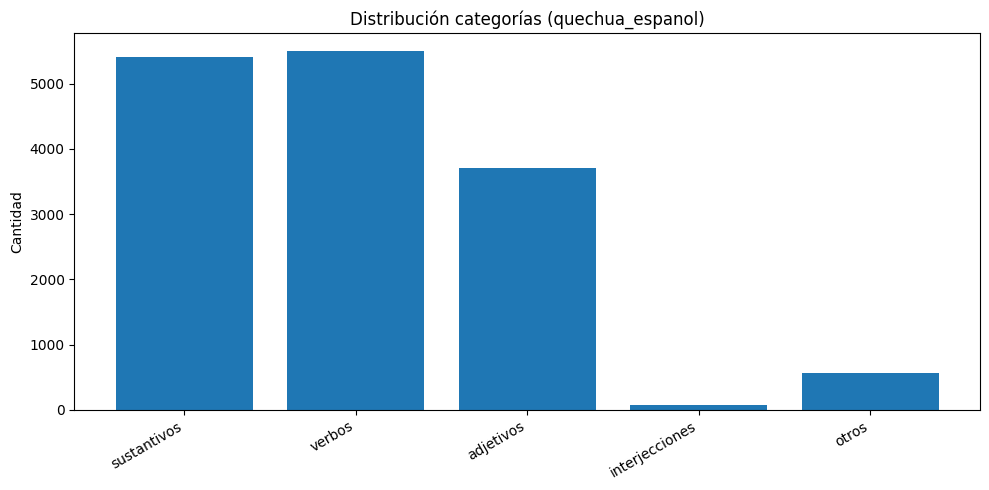

▶ Distribución de categorías (torta)


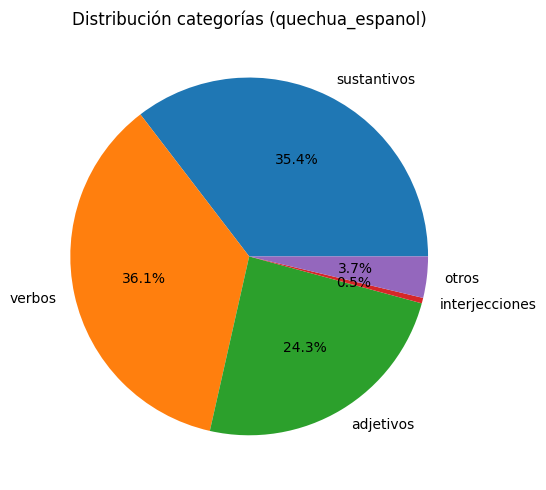

▶ Estadísticas de vocabulario


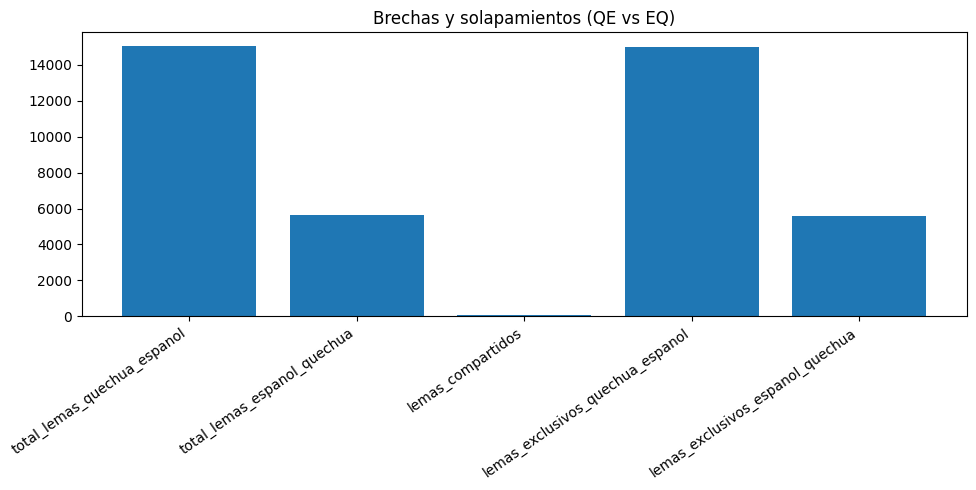

▶ Patrones morfológicos


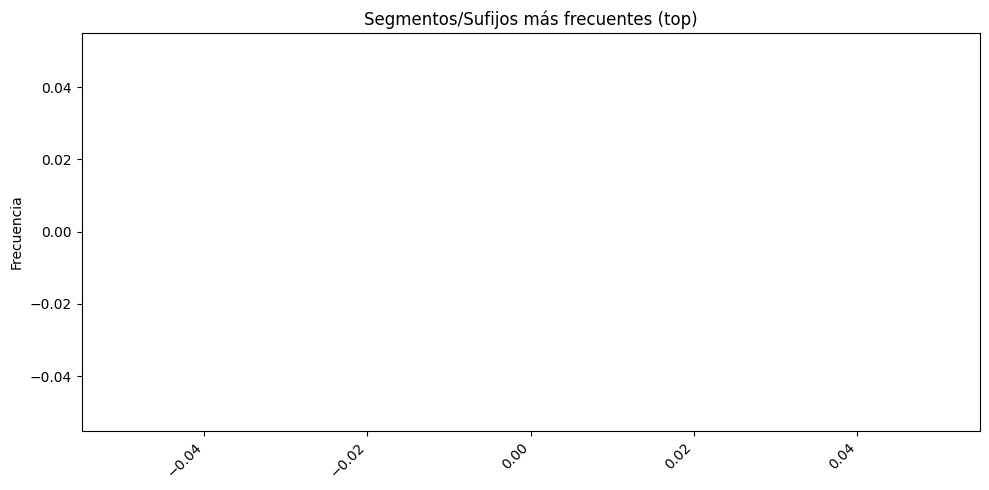

▶ Mapa dialectal (si hay coordenadas)
No hay lat/lon para mapear. (Tus variantes son strings; agrega coordenadas por región si quieres mapa).

🔹 REPORTES

▶ Resumen ejecutivo
RESUMEN EJECUTIVO
- Entradas indexadas: QE=15,053 | EQ=5,621.
- Léxico de raíces (QE): 15,053.
- Cobertura bidireccional: 0.37% (compartidos=56).
- Brechas: QE_exclusivos=14997 | EQ_exclusivos=5565.
- Morfología (promedios): len_raiz=8.5, len_sufijo=0.0, len_palabra=8.5, sufijos/palabra=0.0.
- Evaluación tokenizador: F1_raices=0.6, acc_completa=0.6, cobertura=0.6.
- Dialectos: region_mas_diversa=Pe.Aya., variante_mas_comun=panpay..

▶ Exportar tablas (CSV)
  📄 /content/salida/tabla_vocabulario.csv
  📄 /content/salida/tabla_morfologia.csv
  📄 /content/salida/patrones_lexicos_export.json
  📄 /content/salida/distribucion_dialectal_export.json

▶ Ejemplos representativos
{'ejemplos': [{'lema': 'qatipakuy', 'categoria_gramatical': ['v.'], 'variantes_dialectales': {}, 'morfologia': {'palabra': 'qatipakuy', 'segmentos': 

In [38]:
# ============================================================
# EJECUCIÓN COMPLETA DEL ARCHIVO DE ANÁLISIS
# ============================================================

from archivo_analisis import (
    cargar, consultas, visualizar,
    reportes, validar, demo
)

# ------------------------------------------------------------
# 1) MÓDULO DE CARGA Y GESTIÓN DE RECURSOS
# ------------------------------------------------------------
print("🔹 CONFIGURANDO RUTAS")
cargar.configurar_rutas(base="/content", carpeta_datos="")

print("🔹 CARGANDO DICCIONARIOS")
info_dic = cargar.diccionarios()
print(info_dic)

print("🔹 CARGANDO ESTADÍSTICAS")
print(cargar.estadisticas())

print("🔹 CARGANDO PATRONES MORFOLÓGICOS")
print(cargar.patrones_morfologicos())


# ------------------------------------------------------------
# 2) MÓDULO DE CONSULTAS Y EXPLOTACIÓN DE DATOS
# ------------------------------------------------------------
print("\n🔹 CONSULTAS")

print("\n▶ Buscar palabra (lema directo)")
print(consultas.buscar_palabra("abajo"))

print("\n▶ Buscar palabra por traducción (desde definición)")
print(consultas.buscar_palabra("ura"))

print("\n▶ Obtener estadísticas vocabulario")
print(consultas.obtener_estadisticas("estadisticas_vocabulario"))

print("\n▶ Familias léxicas (raíz 'acha')")
print(consultas.familias_lexicas("acha"))

print("\n▶ Variantes dialectales")
print(consultas.variantes_dialectales("achacha"))

print("\n▶ Variantes dialectales por región (Arg)")
print(consultas.variantes_dialectales("achacha", region="Arg"))

print("\n▶ Análisis morfológico")
print(consultas.analizar_morfologia("rimashankupaq"))


# ------------------------------------------------------------
# 3) MÓDULO DE VISUALIZACIÓN
# ------------------------------------------------------------
print("\n🔹 VISUALIZACIÓN")

print("▶ Distribución de categorías (barras)")
visualizar.graficar_distribucion_categorias(
    fuente="patrones_lexicos",
    dic="quechua_espanol",
    tipo="barras"
)

print("▶ Distribución de categorías (torta)")
visualizar.graficar_distribucion_categorias(
    fuente="patrones_lexicos",
    dic="quechua_espanol",
    tipo="torta"
)

print("▶ Estadísticas de vocabulario")
visualizar.mostrar_estadisticas_vocabulario()

print("▶ Patrones morfológicos")
visualizar.plot_patrones_morfologicos()

print("▶ Mapa dialectal (si hay coordenadas)")
visualizar.mapas_dialectales("achacha")


# ------------------------------------------------------------
# 4) MÓDULO DE REPORTES
# ------------------------------------------------------------
print("\n🔹 REPORTES")

print("\n▶ Resumen ejecutivo")
print(reportes.generar_resumen_ejecutivo())

print("\n▶ Exportar tablas (CSV)")
archivos_exportados = reportes.exportar_tablas(formato="csv")
for a in archivos_exportados:
    print("  📄", a)

print("\n▶ Ejemplos representativos")
print(reportes.ejemplos_representativos())


# ------------------------------------------------------------
# 5) MÓDULO DE VALIDACIÓN INTERACTIVA
# ------------------------------------------------------------
print("\n🔹 VALIDACIÓN")

print("\n▶ Probar tokenización")
print(validar.probar_tokenizacion([
    "wasi",
    "rimashankupaq",
    "achakachalláw"
]))

print("\n▶ Comparar resultados con gold")
print(validar.comparar_resultados())

print("\n▶ Métricas interactivas")
print(validar.metricas_interactivas())


# ------------------------------------------------------------
# 6) MÓDULO DE DEMO Y EJEMPLOS
# ------------------------------------------------------------
print("\n🔹 DEMO")

print("\n▶ Capacidades")
print(demo.mostrar_capacidades())

print("\n▶ Casos de uso")
print(demo.ejecutar_casos_uso())

print("\n▶ Ejemplos aleatorios")
print(demo.generar_ejemplos_aleatorios())

print("\n✅ EJECUCIÓN COMPLETA FINALIZADA")
